# Caso taller: ¿A quién deja entrar el algoritmo?
## Descomposición en valores singulares, eigenfaces y una recomendación de acción

**Grupo 29 — MIAD Aprendizaje No Supervisado — Módulo 2**

---

### El caso

Una empresa que administra edificios corporativos evalúa reemplazar las tarjetas de acceso por reconocimiento facial en los torniquetes. El hardware previsto es de bajo costo, cámaras sencillas y dispositivos con poca memoria y sin GPU, así que no es viable almacenar imágenes completas ni ejecutar modelos pesados.

La propuesta técnica es clásica y liviana. En vez de guardar la foto de cada empleado, el sistema aprende un pequeño conjunto de rostros base, las **eigenfaces**, y describe cada cara con unas pocas coordenadas sobre ellos. Esa base se aprende y se guarda una sola vez, compartida por todos. Incorporar a una persona cuesta solo $K$ números, no su imagen entera. Por eso **elegir $K$ es la decisión central del piloto**.

Debemos responder al cliente:

> **¿Debe la empresa lanzar el piloto de reconocimiento facial basado en eigenfaces? Si es así, ¿con cuántas dimensiones por rostro ($K$) y bajo qué salvaguardas?**

Y sostener esa respuesta frente a cuatro preguntas concretas:

- ¿Cuánto menos hay que guardar por rostro frente a la imagen completa?
- ¿Un accuracy de 90% es tan bueno como suena?
- ¿Qué es peor, rechazar a un empleado o dejar entrar a un extraño?
- ¿Funciona igual de bien para todos los géneros, razas o etnias?

### Los datos

Trabajamos sobre **Labeled Faces in the Wild** (LFW), una base publicada en 2007 por la Universidad de Massachusetts Amherst (Huang et al.) como estándar académico para evaluar reconocimiento facial. Sus 13.233 imágenes se recolectaron de notas de prensa, sobre todo de Yahoo News, así que son casi todas figuras públicas de comienzos de los 2000.

El nombre importa. Antes de LFW los benchmarks usaban fotos de estudio, con luz controlada, fondo uniforme y pose frontal. LFW rompió con eso a propósito, son fotos reales tomadas en condiciones no controladas, con luz variable, poses de perfil, gestos y oclusiones. Esa es la variabilidad que enfrentaría una cámara de torniquete.

Dos consecuencias para el encargo. La primera es que LFW es un **sustituto**, el cliente todavía no tiene fotos de sus empleados, así que el desempeño que midamos es sobre otra población. La segunda es que una base de prensa de esa época está dominada por hombres de mediana edad en cargos públicos, lo que alimenta directamente la pregunta del cliente sobre si el sistema funciona igual para todos.

El método de eigenfaces viene de Sirovich y Kirby (1987) y fue llevado al reconocimiento facial por Turk y Pentland (1991).

Parámetros fijados por el taller para que los resultados sean comparables entre grupos:

- `fetch_lfw_people(min_faces_per_person=25, data_home='data')`
- Partición 80/20 con `random_state=10101`
- `LogisticRegression(solver='sag', random_state=10101, max_iter=1000)`

### Contenido

1. [Exploración de los datos](#paso1)
2. [El rostro promedio](#paso2)
3. [La SVD y las eigenfaces](#paso3)
4. [Compresión y ranking de configuraciones](#paso4)
5. [Verificación de identidad y desempeño](#paso5)
6. [Recomendación](#paso6)

<a id='paso1'></a>
## Paso 1. Exploración de los datos

Antes de comprimir nada necesitamos tres cifras que sostienen todo el argumento posterior:

1. **La dimensión del problema**, es decir cuántos números habría que guardar por rostro sin comprimir. Es el punto de comparación del ahorro que vamos a ofrecer.
2. **El grado de desbalance de la base**, que determina si las métricas de desempeño del Paso 5 son creíbles o engañosas.
3. **La variabilidad dentro de una misma persona**, que es lo que realmente le exige trabajo al sistema.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_people

# Parámetros definidos por el taller
RANDOM_STATE = 10101

# Cargar Labeled Faces in the Wild
lfw = fetch_lfw_people(
    min_faces_per_person=25,
    data_home='data'
)

print("Base cargada correctamente.")

Base cargada correctamente.


In [2]:
print("Forma de lfw.images:", lfw.images.shape)
print("Forma de lfw.data:", lfw.data.shape)
print("Forma de lfw.target:", lfw.target.shape)
print("Número de personas:", len(lfw.target_names))

print("\nPrimeras personas:")
print(lfw.target_names[:10])

Forma de lfw.images: (2588, 62, 47)
Forma de lfw.data: (2588, 2914)
Forma de lfw.target: (2588,)
Número de personas: 42

Primeras personas:
['Alejandro Toledo' 'Alvaro Uribe' 'Andre Agassi' 'Ariel Sharon'
 'Arnold Schwarzenegger' 'Bill Clinton' 'Colin Powell' 'David Beckham'
 'Donald Rumsfeld' 'George W Bush']


In [3]:
n_imagenes = lfw.images.shape[0]
alto = lfw.images.shape[1]
ancho = lfw.images.shape[2]

n_pixeles = alto * ancho
n_personas = len(lfw.target_names)

print(f"Número de imágenes: {n_imagenes}")
print(f"Número de personas: {n_personas}")
print(f"Dimensión de cada imagen: {alto} x {ancho}")
print(f"Píxeles por imagen: {n_pixeles}")
print(f"Forma de la matriz de datos: {lfw.data.shape}")

Número de imágenes: 2588
Número de personas: 42
Dimensión de cada imagen: 62 x 47
Píxeles por imagen: 2914
Forma de la matriz de datos: (2588, 2914)


**La dimensión del problema.** Cada imagen es una matriz de 62 por 47 píxeles en escala de grises. Aplanada en un vector, son **2914 números por rostro**. Ese es el costo de almacenar una cara sin comprimir y el punto de partida del argumento de compresión ante el cliente.

Toda la base es entonces una matriz de 2588 filas, una por imagen, y 2914 columnas, una por píxel. Nótese que hay más columnas que filas, lo que ya anticipa que los píxeles no pueden ser todos independientes entre sí.

In [4]:
conteos = pd.Series(
    lfw.target
).value_counts().sort_index()

df_conteos = pd.DataFrame({
    "persona": lfw.target_names,
    "n_imagenes": conteos.values
})

df_conteos = df_conteos.sort_values(
    "n_imagenes",
    ascending=False
).reset_index(drop=True)

df_conteos.head(10)

,persona,n_imagenes
0,George W Bush,530
1,Colin Powell,236
2,Tony Blair,144
3,Donald Rumsfeld,121
4,Gerhard Schroeder,109
5,Ariel Sharon,77
6,Hugo Chavez,71
7,Junichiro Koizumi,60
8,Jean Chretien,55
9,John Ashcroft,53


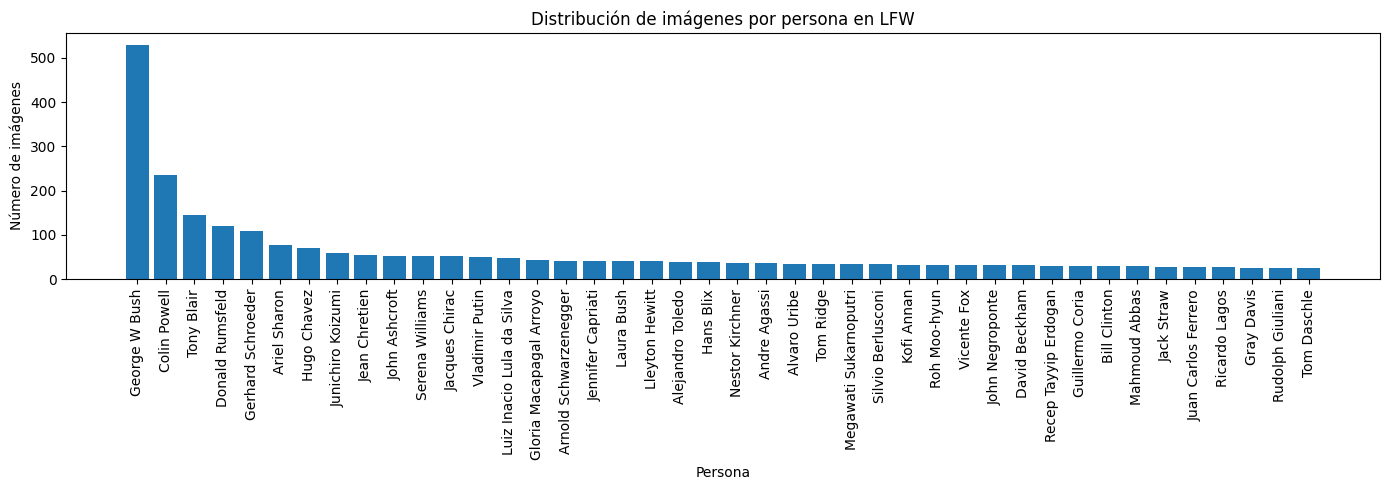

In [5]:
plt.figure(figsize=(14, 5))

plt.bar(
    df_conteos["persona"],
    df_conteos["n_imagenes"]
)

plt.xticks(rotation=90)
plt.xlabel("Persona")
plt.ylabel("Número de imágenes")
plt.title("Distribución de imágenes por persona en LFW")
plt.tight_layout()
plt.show()

In [6]:
persona_max = df_conteos.iloc[0]

print("Persona con más fotografías:")
print(persona_max)

Persona con más fotografías:
persona       George W Bush
n_imagenes              530
Name: 0, dtype: object


In [7]:
proporcion_max = persona_max["n_imagenes"] / n_imagenes

print(
    f"\nLa persona con más imágenes representa "
    f"{proporcion_max:.2%} de toda la base."
)


La persona con más imágenes representa 20.48% de toda la base.


**El desbalance** La base tiene 2588 imágenes repartidas entre 42 personas. Si estuvieran distribuidas de forma pareja, cada una tendría unas 62 fotos. George W Bush concentra **530 imágenes, el 20.48% de toda la base**, unas 8.6 veces el promedio. Le siguen Colin Powell con 236 y Tony Blair con 144. Esto tiene una consecuencia directa que desarrollaremos en el Paso 5. Si construimos un detector para Bush, un sistema que respondiera siempre "no es Bush" acertaría en cerca del 80% de los casos sin haber aprendido nada. **Cualquier accuracy que le presentemos al cliente debe leerse contra ese piso**, no contra el 0%.

Una segunda observación, que retomaremos al hablar de equidad en el Paso 6. Las cinco personas con más fotografías son todas hombres, políticos y famosos. La composición de esta base no se parece a la nómina de un edificio corporativo.

In [8]:
nombre = "Serena Williams"

indice_serena = np.where(lfw.target_names == nombre)[0][0]

indices_imagenes_serena = np.where(
    lfw.target == indice_serena
)[0]

print("Número de imágenes de Serena Williams:",
      len(indices_imagenes_serena))

Número de imágenes de Serena Williams: 52


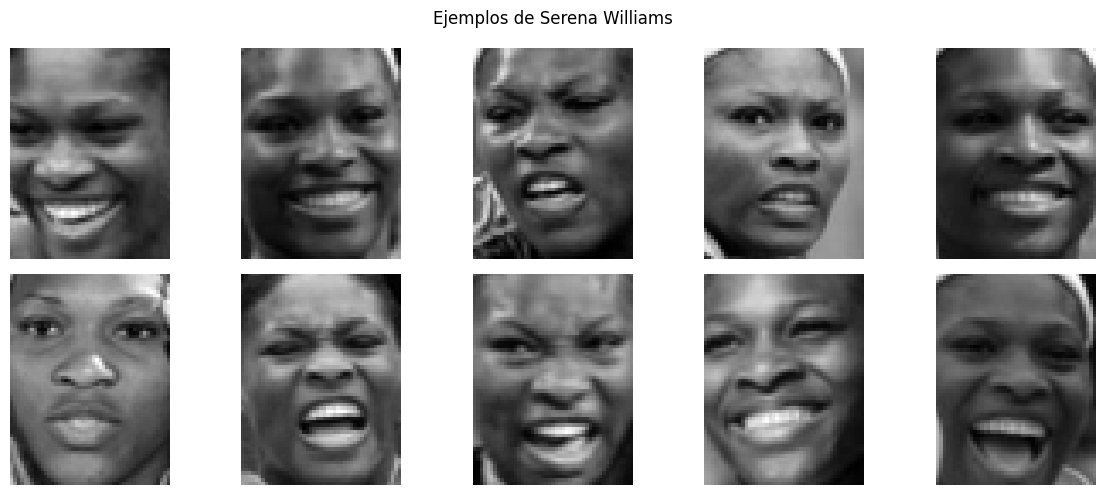

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, idx in zip(
    axes.ravel(),
    indices_imagenes_serena[:10]
):
    ax.imshow(lfw.images[idx], cmap="gray")
    ax.axis("off")

plt.suptitle("Ejemplos de Serena Williams")
plt.tight_layout()
plt.show()

**La variabilidad dentro de una misma persona.** Serena Williams tiene 52 imágenes en la base, y basta mirarlas para ver el problema real del reconocimiento facial.

Entre fotos de la misma persona cambian la iluminación y las sombras, la orientación de la cabeza, la expresión facial, el peinado y accesorios, y el encuadre del rostro dentro del recuadro. Ninguno de esos cambios altera la identidad, pero todos alteran los 2914 píxeles.

Eso es exactamente lo que le exigimos al sistema: encontrar una representación donde dos fotos de la misma persona bajo condiciones distintas queden cerca, y fotos de personas distintas queden lejos. Guardar los píxeles crudos no logra eso, porque un simple cambio de iluminación mueve todos los valores a la vez. Ese es el motivo por el que necesitamos las eigenfaces y no una simple compresión de imagen.

### Cierre del Paso 1

1. **2914 números por rostro** sin comprimir, la cifra contra la que mediremos todo ahorro.
2. **La base está muy desbalanceada**, Bush concentra el 20.48% de las imágenes, así que un detector trivial que siempre diga "no" partiría con cerca de 80% de accuracy.
3. **Dentro de una misma persona hay mucha variación** de luz, pose y expresión, y esa es la dificultad real que el sistema debe resolver.

<a id='paso2'></a>
## Paso 2. El rostro promedio

Antes de descomponer hay que centrar los datos. Calculamos el rostro promedio, lo restamos de cada imagen y justificamos por qué ese paso es obligatorio y hasta dónde llega.

Dimensión del rostro promedio: (2914,)


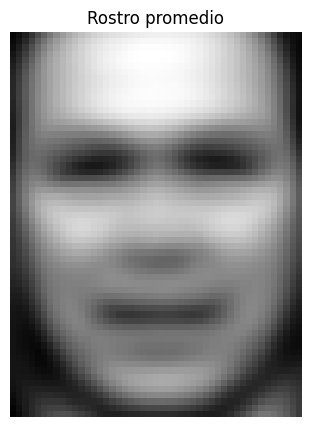

In [10]:
# Rostro promedio
rostro_promedio = lfw.data.mean(axis=0)

print("Dimensión del rostro promedio:", rostro_promedio.shape)

# Volver de vector de 2914 números a imagen 62x47
rostro_promedio_img = rostro_promedio.reshape(
    lfw.images.shape[1],
    lfw.images.shape[2]
)

plt.figure(figsize=(4, 5))
plt.imshow(rostro_promedio_img, cmap="gray")
plt.title("Rostro promedio")
plt.axis("off")
plt.show()

**Qué es el rostro promedio** No es la foto de nadie, es el promedio de cada uno de los 2914 píxeles a través de las 2588 imágenes, es decir un rostro que no existe. Tiene aspecto de cara por cómo está construida la base: LFW viene alineada, todas las fotos están recortadas y centradas de modo que ojos, nariz y boca caen aproximadamente en las mismas coordenadas. Al promediar se refuerza lo común a todas las imágenes, la estructura facial genérica, y se cancela lo que varía entre ellas, los rasgos individuales.

Si las imágenes no estuvieran alineadas el promedio sería una mancha gris sin forma. Que se vea una cara es evidencia de que el preprocesamiento de LFW funciona, y también una advertencia para el cliente: **el sistema en producción necesitará detectar y alinear el rostro antes de proyectarlo**, porque la cámara del torniquete no entrega imágenes recortadas.

In [11]:
# Centrar todas las imágenes
X = lfw.data

X_centrado = X - rostro_promedio

print("Dimensión X original:", X.shape)
print("Dimensión X centrado:", X_centrado.shape)

# Comprobación matemática
print(
    "Máximo valor absoluto de la media después de centrar:",
    np.abs(X_centrado.mean(axis=0)).max()
)

Dimensión X original: (2588, 2914)
Dimensión X centrado: (2588, 2914)
Máximo valor absoluto de la media después de centrar: 1.4413937e-06


**Qué queda al restar el promedio y por qué hay que hacerlo** Lo que queda en cada imagen centrada es la desviación respecto al rostro típico, o sea en qué se diferencia esta cara de la cara genérica. La identidad está ahí, no en el promedio, y por eso ese residuo es lo que vale la pena descomponer.

El motivo técnico es la equivalencia vista en clase, PCA sobre $X$ equivale a SVD sobre $X$ centrada. Sin centrar, el primer vector singular apuntaría hacia la media de los datos y no hacia la dirección de máxima variación: gastaríamos la primera y más valiosa dimensión describiendo algo que ya conocemos y que es igual para todos. Como el rostro promedio se guarda una sola vez y se comparte, no tiene sentido pagarlo dentro de las $K$ coordenadas de cada empleado. La verificación numérica de la celda anterior confirma que tras centrar la media de cada píxel queda esencialmente en cero.

**Decisión sobre estandarizar: no lo hacemos.** En el taller anterior, con las nueve variables de las ciudades, estandarizar era obligatorio porque tenían unidades y escalas incomparables. Aquí la conclusión se invierte por tres razones.

1. **Todas las variables ya comparten escala.** Los 2914 píxeles se miden en la misma unidad de intensidad y en el mismo rango, así que ninguna domina artificialmente por sus unidades, que era justamente el problema que la estandarización resuelve.
2. **Dividir por la desviación estándar amplificaría el ruido.** Los píxeles del fondo y de los bordes varían poco entre imágenes, y al dividirlos por una desviación pequeña su variación residual, que es en buena medida ruido de captura, quedaría inflada hasta pesar tanto como la de los píxeles del centro del rostro, que son los informativos.
3. **Distorsionaría el sentido de la reconstrucción.** Queremos reconstruir imágenes y el error que importa es el de intensidad de píxel. Estandarizar optimizaría un error en unidades de desviación por píxel, que no corresponde a lo que evalúa el ojo ni el cliente.

Centramos entonces pero no escalamos.

In [12]:
# Identificar a Serena Williams
nombre = "Serena Williams"

id_serena = np.where(lfw.target_names == nombre)[0][0]

indices_serena = np.where(
    lfw.target == id_serena
)[0]

print("ID de Serena:", id_serena)
print("Número de imágenes de Serena:", len(indices_serena))

ID de Serena: 35
Número de imágenes de Serena: 52


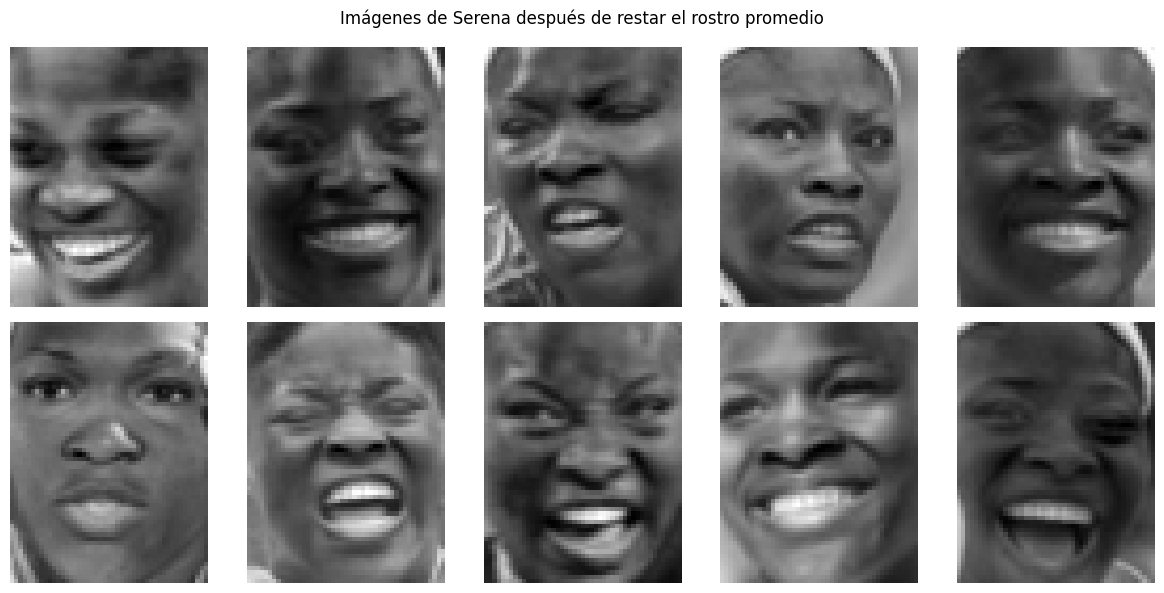

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for ax, idx in zip(axes.ravel(), indices_serena[:10]):

    imagen_centrada = X_centrado[idx].reshape(
        lfw.images.shape[1],
        lfw.images.shape[2]
    )

    ax.imshow(imagen_centrada, cmap="gray")
    ax.axis("off")

plt.suptitle("Imágenes de Serena después de restar el rostro promedio")
plt.tight_layout()
plt.show()

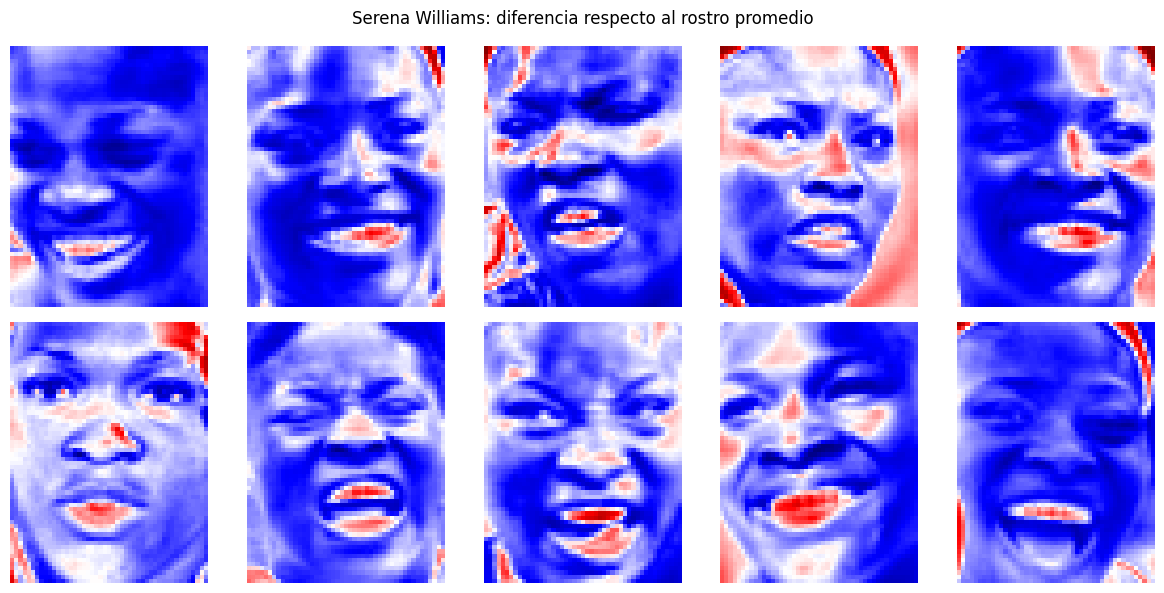

In [14]:
limite = np.max(np.abs(X_centrado[indices_serena[:10]]))

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for ax, idx in zip(axes.ravel(), indices_serena[:10]):

    imagen_centrada = X_centrado[idx].reshape(
        lfw.images.shape[1],
        lfw.images.shape[2]
    )

    ax.imshow(
        imagen_centrada,
        cmap="seismic",
        vmin=-limite,
        vmax=limite
    )

    ax.axis("off")

plt.suptitle("Serena Williams: diferencia respecto al rostro promedio")
plt.tight_layout()
plt.show()

Las dos visualizaciones muestran lo mismo con distinta codificación. En escala de grises las imágenes centradas se ven apagadas porque muchos valores son negativos y el mapa los recorta. El mapa divergente es más honesto: **blanco es igual al promedio, rojo más brillante que el promedio y azul más oscuro**.

Ahí se ve qué codifica el residuo. Los patrones más marcados no son los rasgos de Serena sino la **estructura de iluminación** de cada foto, de qué lado viene la luz y dónde caen las sombras.

### Cierre del Paso 2

1. El rostro promedio es una cara genérica sin identidad, y su aspecto depende de que LFW venga alineada, así que en producción hará falta un paso previo de detección y alineación.
2. **Centramos** porque PCA equivale a SVD sobre datos centrados, y sin centrar desperdiciaríamos la primera dimensión describiendo el promedio en vez de la variación.
3. **No estandarizamos**, porque todos los píxeles comparten escala y dividir por la desviación amplificaría el ruido del fondo y distorsionaría el error de reconstrucción que le importa al cliente.

<a id='paso3'></a>
## Paso 3. La SVD y las eigenfaces

Descomponemos la matriz de imágenes centradas y examinamos qué encontró. Aquí es donde aparecen las eigenfaces, la base compartida que el sistema guardaría una sola vez.

In [15]:
U, S, Vt = np.linalg.svd(
    X_centrado,
    full_matrices=False
)

print("X centrado:", X_centrado.shape)
print("U:", U.shape)
print("S:", S.shape)
print("Vt:", Vt.shape)

X centrado: (2588, 2914)
U: (2588, 2588)
S: (2588,)
Vt: (2588, 2914)


**Qué acabamos de calcular** La descomposición parte la matriz centrada en tres factores, $X = USV'$, usando la versión delgada porque tenemos más columnas que filas y la $U$ completa sería innecesariamente grande.

Lo que nos interesa de cada pieza es distinto. Las **filas de $V'$** son las direcciones en el espacio de 2914 píxeles, y redibujadas como imágenes son las eigenfaces. Los **valores singulares en $S$** miden cuánto se estira la nube de datos en cada una de esas direcciones. Y $US$ son las coordenadas de cada imagen sobre esa base, que es justamente lo que el sistema guardaría por empleado.

La conexión con el taller anterior es directa. Los eigenvalores del PCA son el cuadrado de los valores singulares, $\lambda_i = \sigma_i^2$, y por eso la proporción de varianza se calcula con $\sigma^2$ y no con $\sigma$. Usamos SVD y no la eigendescomposición de $X'X$ porque formar esa matriz de 2914 por 2914 sería costoso y numéricamente inestable.

In [16]:
varianza_explicada = (S ** 2) / np.sum(S ** 2)

varianza_acumulada = np.cumsum(varianza_explicada)

print("Varianza primera componente:",
      varianza_explicada[0])

print("Varianza acumulada primeras 10:",
      varianza_acumulada[9])

Varianza primera componente: 0.2407484
Varianza acumulada primeras 10: 0.6241775


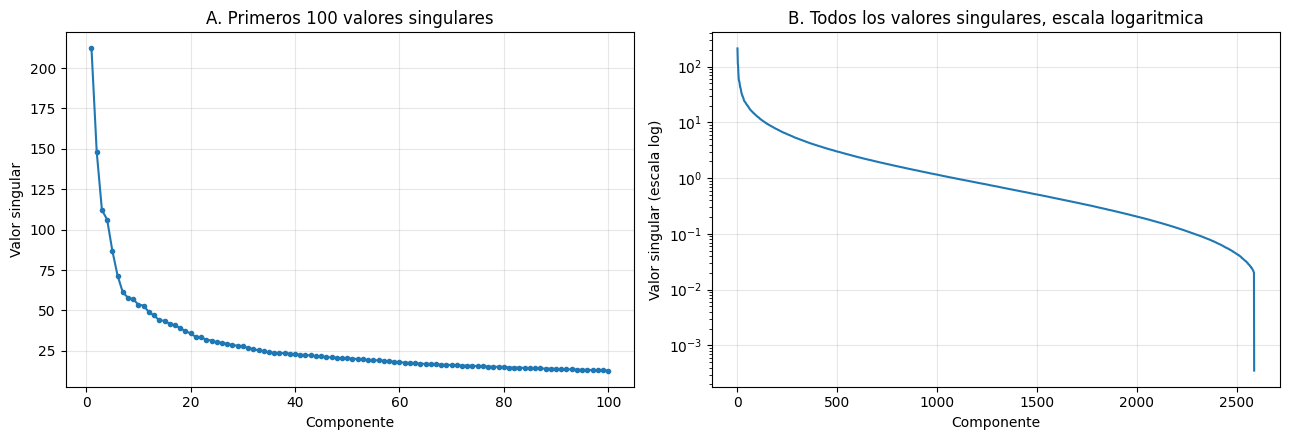

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# A. Primeros 100 valores singulares, para ver el codo
axes[0].plot(np.arange(1, 101), S[:100], marker=".")
axes[0].set_xlabel("Componente")
axes[0].set_ylabel("Valor singular")
axes[0].set_title("A. Primeros 100 valores singulares")
axes[0].grid(alpha=0.3)

# B. Todos, en escala logaritmica
axes[1].semilogy(np.arange(1, len(S) + 1), S)
axes[1].set_xlabel("Componente")
axes[1].set_ylabel("Valor singular (escala log)")
axes[1].set_title("B. Todos los valores singulares, escala logaritmica")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

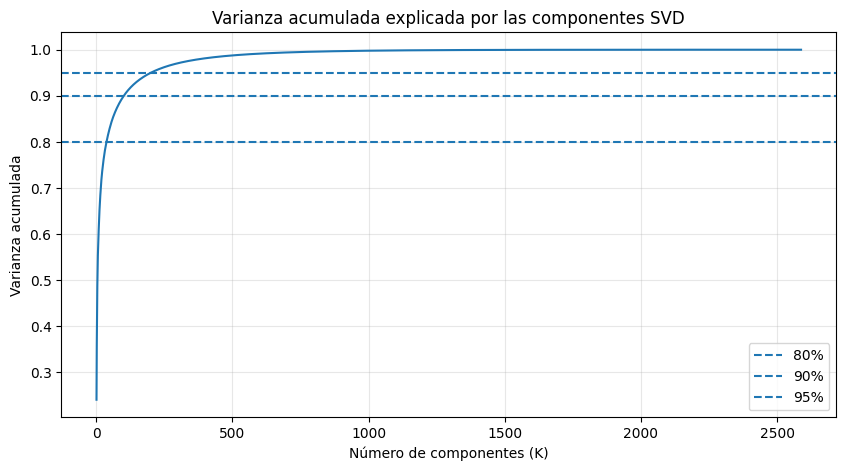

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    np.arange(1, len(varianza_acumulada) + 1),
    varianza_acumulada
)

plt.axhline(0.80, linestyle="--", label="80%")
plt.axhline(0.90, linestyle="--", label="90%")
plt.axhline(0.95, linestyle="--", label="95%")

plt.xlabel("Número de componentes (K)")
plt.ylabel("Varianza acumulada")
plt.title("Varianza acumulada explicada por las componentes SVD")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [19]:
k_80 = np.searchsorted(varianza_acumulada, 0.80) + 1
k_90 = np.searchsorted(varianza_acumulada, 0.90) + 1
k_95 = np.searchsorted(varianza_acumulada, 0.95) + 1

print("Componentes para 80%:", k_80)
print("Componentes para 90%:", k_90)
print("Componentes para 95%:", k_95)

Componentes para 80%: 38
Componentes para 90%: 102
Componentes para 95%: 201


**Cuánta redundancia tienen los píxeles de un rostro** La caída de los valores singulares es abrupta y los umbrales lo confirman:

| Varianza capturada | Componentes necesarios | Frente a los 2914 originales |
|---|---|---|
| 80% | 38 | 1.3% |
| 90% | 102 | 3.5% |
| 95% | 201 | 6.9% |

La primera dirección sola explica el 24.1% de toda la variación, y las diez primeras juntas el 62.4%.

La lectura para el cliente es que **los 2914 píxeles de un rostro no son 2914 piezas de información independientes**. Los píxeles vecinos están fuertemente correlacionados, la frente es de un tono parejo, las mejillas también, la estructura de una cara es muy predecible. La información real de un rostro vive en un espacio de unas pocas decenas de dimensiones, no de miles. Ese es el fundamento del ahorro que vamos a proponer.

Conviene notar de una vez algo que matizará el Paso 5: **varianza capturada no es lo mismo que capacidad de identificar a alguien**. Son dos criterios distintos y no tienen por qué coincidir en el mismo $K$.

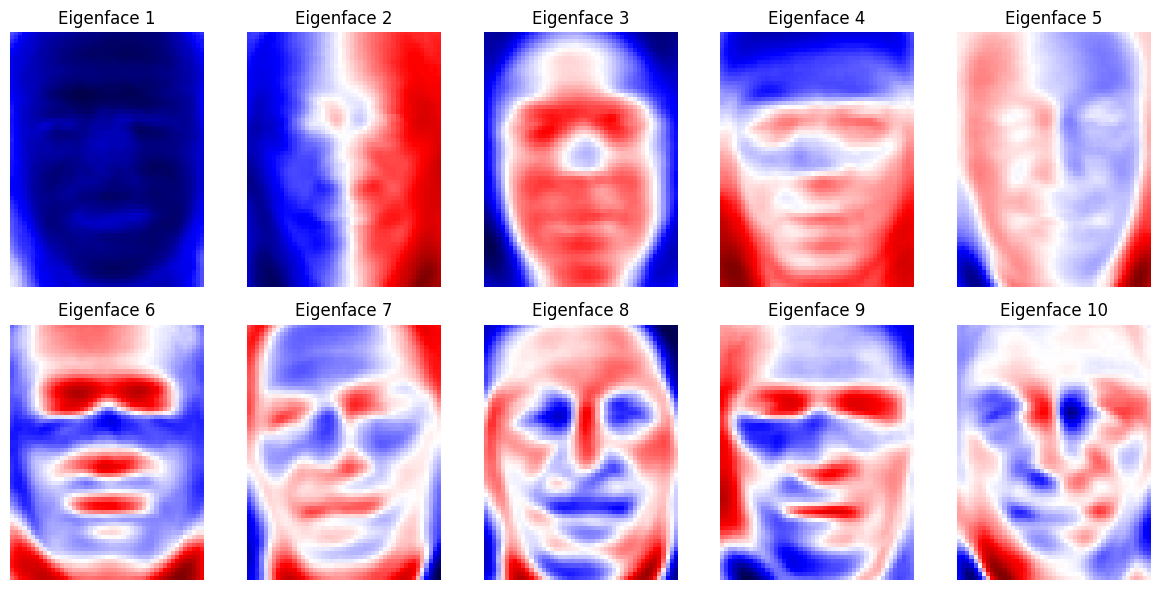

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.ravel()):

    eigenface = Vt[i].reshape(
        lfw.images.shape[1],
        lfw.images.shape[2]
    )

    limite = np.max(np.abs(eigenface))

    ax.imshow(
        eigenface,
        cmap="seismic",
        vmin=-limite,
        vmax=limite
    )

    ax.set_title(f"Eigenface {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

**Qué capturan las primeras eigenfaces** El código de color es el mismo de antes, rojo por encima del promedio y azul por debajo. Leídas en orden cuentan una historia clara.

Las **primeras tres o cuatro no capturan rasgos, capturan luz**. La eigenface 1 es prácticamente un bloque uniforme sobre toda la cara, es decir la diferencia entre fotos globalmente más claras y más oscuras. La 2 parte la imagen en mitad izquierda contra mitad derecha, que es luz lateral. La 3 opone el centro del rostro contra el fondo, y la 4 opone la parte superior contra la inferior, luz cenital contra frontal.

A partir de la sexta empiezan a aparecer **estructuras faciales**, bandas horizontales que coinciden con la línea de los ojos y con la boca. Entre la séptima y la décima ya se distinguen ojos, nariz y boca como regiones diferenciadas, y el detalle espacial es cada vez más fino.

Esto explica el resultado incómodo del Paso 5. **Las direcciones de mayor varianza en una base de rostros describen las condiciones en que se tomó la foto, no quién aparece en ella.** La identidad no está en las primeras componentes, está repartida en las decenas siguientes. Por eso un $K$ muy pequeño puede reconstruir una cara de aspecto correcto y aun así servir muy mal para distinguir a una persona de otra.

**Cómo explicarle una eigenface al cliente, sin jerga.** Piense en cómo se describe un color: en vez de guardar la definición completa de un tono, se dice cuánto tiene de rojo, cuánto de verde y cuánto de azul. Tres números y basta, porque rojo, verde y azul son los ingredientes básicos con los que se arma cualquier color.

Las eigenfaces son los ingredientes básicos de una cara, aprendidos a partir de miles de fotos. La primera aporta qué tan iluminada está, la segunda de qué lado viene la luz, y las siguientes van agregando forma de la mandíbula, separación de los ojos, ancho de la nariz. Cualquier rostro se arma mezclando esos ingredientes en distintas proporciones, y **esas proporciones son las únicas que hay que guardar por empleado**. La lista de ingredientes es la misma para todos y se guarda una sola vez.

### Cierre del Paso 3

1. Bastan **38 componentes para el 80% de la varianza, 102 para el 90% y 201 para el 95%**, frente a los 2914 píxeles originales. Los píxeles de un rostro son enormemente redundantes.
2. Las primeras eigenfaces **capturan iluminación, no identidad**. Los rasgos faciales aparecen recién a partir de la sexta.
3. De ahí se desprende la advertencia central del análisis: elegir $K$ por varianza capturada y elegirlo por capacidad de identificar son dos criterios distintos. El Paso 5 dirá cuál manda.

<a id='paso4'></a>
## Paso 4. Compresión y ranking de configuraciones

Cada rostro se aproxima con $K$ coordenadas sobre las eigenfaces más el rostro promedio. Aquí comparamos configuraciones de $K$ por lo que le cuesta al cliente y por lo que le devuelve en calidad.

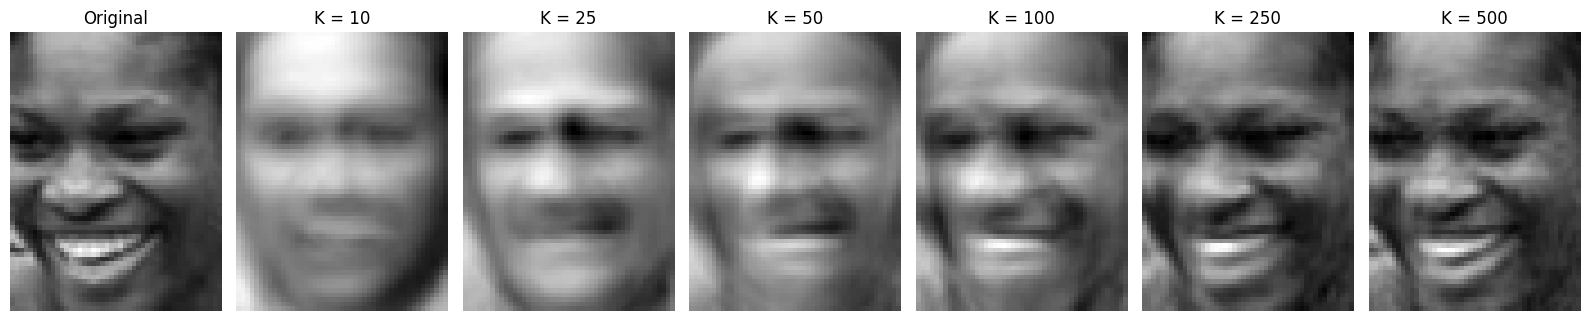

In [21]:
Ks = [10, 25, 50, 100, 250, 500]

# Elegimos una fotografía de Serena
idx = indices_serena[0]

x_original = X[idx]
x_centrada = X_centrado[idx]

fig, axes = plt.subplots(1, len(Ks) + 1, figsize=(16, 4))

# Original
axes[0].imshow(
    x_original.reshape(62, 47),
    cmap="gray"
)
axes[0].set_title("Original")
axes[0].axis("off")

# Reconstrucciones
for ax, K in zip(axes[1:], Ks):

    # Primeras K eigenfaces
    Vk = Vt[:K, :]

    # Coordenadas del rostro sobre esas eigenfaces
    coordenadas = x_centrada @ Vk.T

    # Reconstrucción
    reconstruccion_centrada = coordenadas @ Vk

    # Devolver el rostro promedio
    reconstruccion = reconstruccion_centrada + rostro_promedio

    ax.imshow(
        reconstruccion.reshape(62, 47),
        cmap="gray"
    )

    ax.set_title(f"K = {K}")
    ax.axis("off")

plt.tight_layout()
plt.show()

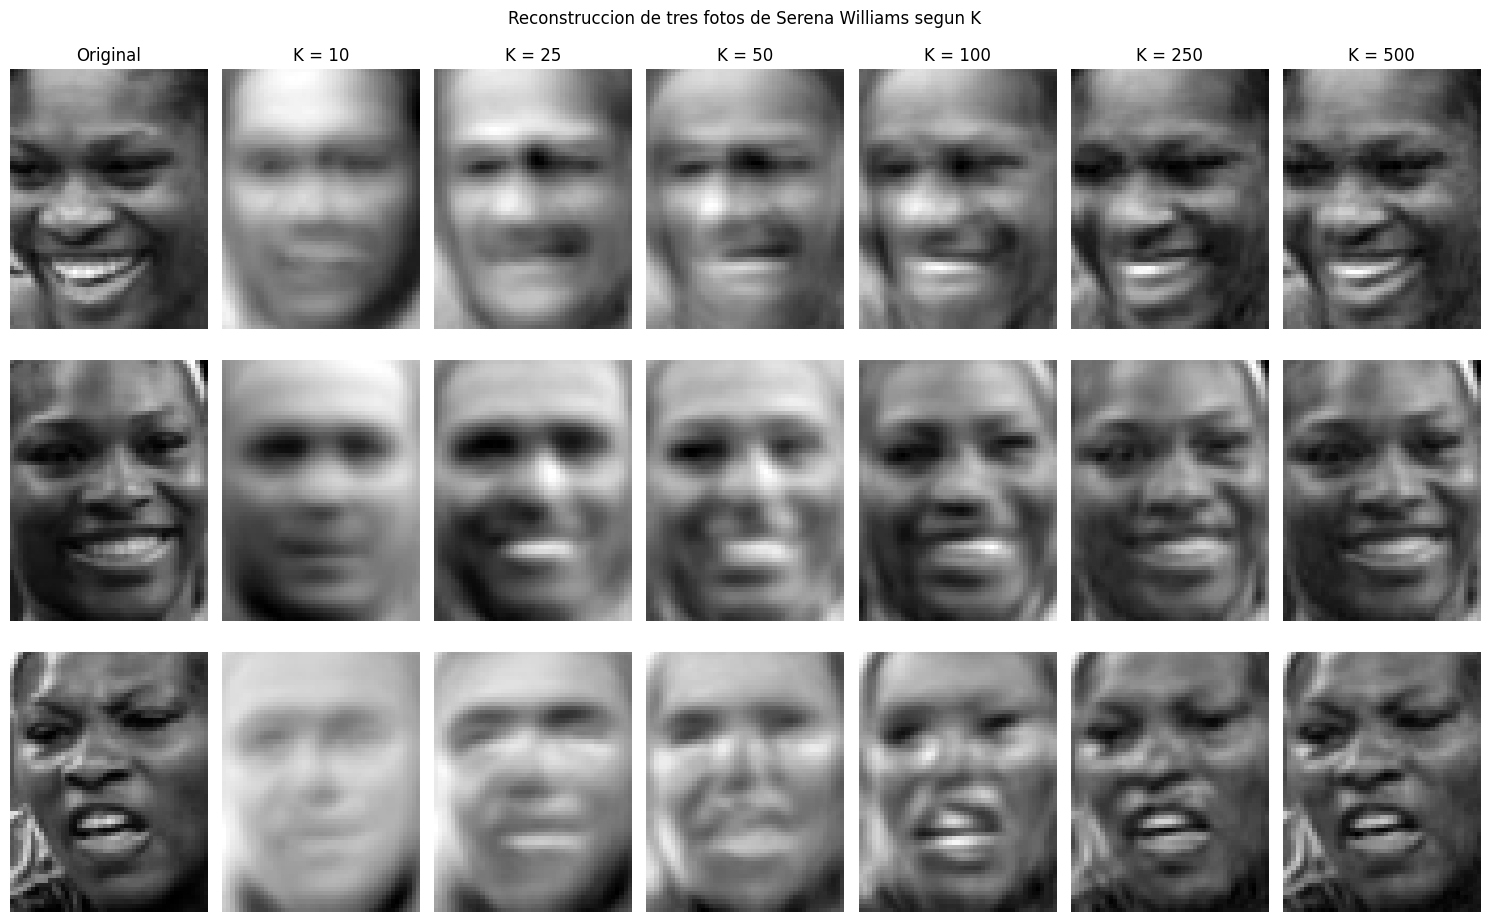

In [22]:
# La guia pide comparar varias imagenes, no una sola.
# Tres fotos de Serena en condiciones distintas, contra la misma grilla de K.
fotos = indices_serena[:3]

fig, axes = plt.subplots(len(fotos), len(Ks) + 1, figsize=(15, 3.2 * len(fotos)))

for fila, idx in enumerate(fotos):

    axes[fila, 0].imshow(X[idx].reshape(62, 47), cmap="gray")
    axes[fila, 0].axis("off")
    if fila == 0:
        axes[fila, 0].set_title("Original")

    for col, K in enumerate(Ks, start=1):
        Vk = Vt[:K, :]
        coordenadas = X_centrado[idx] @ Vk.T
        reconstruccion = coordenadas @ Vk + rostro_promedio

        axes[fila, col].imshow(reconstruccion.reshape(62, 47), cmap="gray")
        axes[fila, col].axis("off")
        if fila == 0:
            axes[fila, col].set_title(f"K = {K}")

plt.suptitle("Reconstruccion de tres fotos de Serena Williams segun K")
plt.tight_layout()
plt.show()

**Una aclaración necesaria: no se omiten píxeles** Al ver que 201 componentes bastan para el 95% de la varianza es natural leerlo como si se descartaran 2700 píxeles. No es eso lo que ocurre.

Cada eigenface es un vector de 2914 números, uno por píxel, y las vimos como imágenes completas. Cada coordenada que guardamos es el producto punto de la cara centrada con una eigenface entera, es decir **una suma ponderada de los 2914 píxeles**. Todos los píxeles participan en todas las coordenadas.

Lo que se descarta son **direcciones**, no píxeles, y cada dirección descartada también involucraba a los 2914. No estamos eliminando columnas de la matriz, estamos cambiando de sistema de coordenadas y quedándonos con los ejes donde los datos efectivamente varían.

La grilla de arriba lo confirma. Si hubiéramos omitido píxeles, las caras reconstruidas tendrían huecos o recortes. Lo que se ve son **caras completas, con sus 2914 píxeles llenos**, apenas más borrosas al bajar $K$. Lo que se pierde es detalle fino y textura, no regiones de la imagen.

**A partir de qué $K$ la cara es reconocible.** Con $K = 10$ hay una cara pero es genérica, podría ser casi cualquier persona. Con $K = 25$ aparecen ojos y boca y ya se distingue el gesto. Entre $K = 50$ y $K = 100$ la expresión y la estructura del rostro son claramente los de Serena. De $K = 250$ en adelante la ganancia visual es marginal.

Ahora bien, la guía pregunta si ese es el criterio que le importa al cliente, y la respuesta es que no. El torniquete no necesita una foto bonita, necesita **decidir si quien está enfrente es quien dice ser**. Reconocible para un humano y suficiente para verificar identidad son dos umbrales distintos, y el Paso 5 dirá cuál manda.

In [23]:
resultados = []

for K in Ks:

    Vk = Vt[:K, :]

    # Coordenadas todas las imágenes
    Z = X_centrado @ Vk.T

    # Reconstrucción total imágenes
    X_recon_c = Z @ Vk
    X_recon = X_recon_c + rostro_promedio

    # Error cuadrático medio
    mse = np.mean((X - X_recon) ** 2)

    resultados.append({
        "K": K,
        "varianza_capturada": varianza_acumulada[K - 1],
        "porcentaje_dimensiones": K / 2914 * 100,
        "reduccion_porcentual": (1 - K / 2914) * 100,
        "MSE_reconstruccion": mse
    })

ranking = pd.DataFrame(resultados)

ranking

,K,varianza_capturada,porcentaje_dimensiones,reduccion_porcentual,MSE_reconstruccion
0,10,0.624178,0.343171,99.656829,0.009314
1,25,0.752368,0.857927,99.142073,0.006137
2,50,0.830991,1.715854,98.284146,0.004189
3,100,0.898928,3.431709,96.568291,0.002505
4,250,0.962235,8.579272,91.420728,0.000936
5,500,0.987640,17.158545,82.841455,0.000306


In [24]:
n_pixeles = 2914

filas = []
for K in Ks:
    # Costo fijo, se guarda una sola vez y se comparte
    costo_base = K * n_pixeles          # las K eigenfaces
    costo_promedio = n_pixeles          # el rostro promedio
    costo_fijo = costo_base + costo_promedio

    # Punto de equilibrio en numero de empleados frente a guardar la foto cruda
    # n * n_pixeles  =  costo_fijo + n * K   =>   n = costo_fijo / (n_pixeles - K)
    equilibrio = costo_fijo / (n_pixeles - K)

    filas.append({
        "K": K,
        "numeros_por_empleado": K,
        "%_frente_a_foto_cruda": K / n_pixeles * 100,
        "costo_fijo_compartido": costo_fijo,
        "empleados_para_equilibrio": np.ceil(equilibrio)
    })

almacenamiento = pd.DataFrame(filas)
almacenamiento.round(2)

,K,numeros_por_empleado,%_frente_a_foto_cruda,costo_fijo_compartido,empleados_para_equilibrio
0,10,10,0.34,32054,12.0
1,25,25,0.86,75764,27.0
2,50,50,1.72,148614,52.0
3,100,100,3.43,294314,105.0
4,250,250,8.58,731414,275.0
5,500,500,17.16,1459914,605.0


**La traducción a lenguaje de negocio** El costo marginal de incorporar a un empleado es solo $K$ números, porque la base de eigenfaces y el rostro promedio se guardan una sola vez y se comparten entre todos.

| $K$ | Varianza capturada | Se guarda por empleado | Frente a la foto cruda |
|---|---|---|---|
| 10 | 62.4% | 10 números | 0.3% |
| 25 | 75.2% | 25 números | 0.9% |
| 50 | 83.1% | 50 números | 1.7% |
| 100 | 89.9% | 100 números | 3.4% |
| 250 | 96.2% | 250 números | 8.6% |
| 500 | 98.8% | 500 números | 17.2% |

Dicho para el cliente, **con $K = 100$ almacenamos el 3.4% de los números que exigiría la foto completa**, es decir un ahorro del 96.6% por empleado.

Con una salvedad honesta que la tabla anterior hace explícita. La base compartida no es gratis, y hasta que no haya suficientes empleados no se amortiza. Con $K = 100$ el punto de equilibrio está en torno a un centenar de personas, y con $K = 250$ sube. Para un edificio corporativo el umbral se supera sin problema, pero es una cifra que conviene tener lista si el cliente pregunta por el caso de una sede pequeña.

Nótese además que la tabla **ordena configuraciones bajo criterios explícitos, no declara un ganador**. Por varianza capturada gana siempre el $K$ más grande, y por costo de almacenamiento gana siempre el más chico. El criterio que rompe el empate es el desempeño en verificación de identidad, que es el Paso 5.

In [25]:
# El MSE global promedia sobre toda la base y puede esconder diferencias
# entre personas. Lo desagregamos.
id_bush_p4 = np.where(lfw.target_names == "George W Bush")[0][0]
idx_bush_p4 = np.where(lfw.target == id_bush_p4)[0]

filas = []
for K in Ks:
    Vk = Vt[:K, :]
    X_rec = (X_centrado @ Vk.T) @ Vk + rostro_promedio

    # error cuadratico medio por imagen
    err = ((X - X_rec) ** 2).mean(axis=1)

    # brillo medio, para ver hacia donde tira la reconstruccion
    filas.append({
        "K": K,
        "MSE_global": err.mean(),
        "MSE_Bush": err[idx_bush_p4].mean(),
        "MSE_Serena": err[indices_serena].mean(),
        "razon_Serena_sobre_Bush": err[indices_serena].mean() / err[idx_bush_p4].mean(),
        "brillo_Serena_reconstruida": X_rec[indices_serena].mean(),
    })

error_por_persona = pd.DataFrame(filas)

print(f"Brillo medio del rostro promedio : {rostro_promedio.mean():.4f}")
print(f"Brillo medio de Serena, original : {X[indices_serena].mean():.4f}")
print(f"Brillo medio de Bush, original   : {X[idx_bush_p4].mean():.4f}")
print()
error_por_persona.round(5)

Brillo medio del rostro promedio : 0.4984
Brillo medio de Serena, original : 0.3429
Brillo medio de Bush, original   : 0.5123



,K,MSE_global,MSE_Bush,MSE_Serena,razon_Serena_sobre_Bush,brillo_Serena_reconstruida
0,10,0.00931,0.00857,0.01153,1.34508,0.34188
1,25,0.00614,0.00545,0.00782,1.43355,0.34275
2,50,0.00419,0.00370,0.00526,1.42256,0.34286
3,100,0.00250,0.00222,0.00304,1.37311,0.34290
4,250,0.00094,0.00085,0.00102,1.20148,0.34293
5,500,0.00031,0.00029,0.00030,1.04035,0.34293


**Un hallazgo que el promedio global escondía** El MSE de la tabla anterior promedia sobre las 2588 imágenes y sugiere que la compresión trata a todas las caras por igual. Desagregado por persona aparece otra cosa.

**El error de reconstrucción de Serena es sistemáticamente mayor que el de Bush.** La razón entre ambos es 1.35 con $K = 10$, sube a 1.43 con $K = 25$, y sigue por encima de 1.35 hasta $K = 100$. Solo se acerca a la paridad en $K = 500$, con 1.04. Dicho de otro modo, la misma configuración reconstruye a Serena entre un 20% y un 43% peor que a Bush.

La explicación es estructural. Bush aporta 530 de las 2588 imágenes, el 20% de la base, así que las direcciones de máxima varianza están ajustadas en buena medida a fotos suyas. **Las eigenfaces no son una base neutral, están sesgadas hacia quien más aparece en los datos con los que se construyeron.**

Lo relevante para la decisión es dónde se abre esa brecha. Con $K$ grande la desigualdad prácticamente desaparece, porque con suficientes direcciones todo el mundo se reconstruye bien. **Es justamente en el rango de $K$ bajo, el que interesa al cliente por costo y por hardware barato, donde la disparidad es mayor.** Ahorrar dimensiones no es neutral: el ahorro se paga de forma desigual según a quién se parezca la base de entrenamiento.

**Una corrección sobre la lectura visual.** Mirando la grilla de reconstrucciones es tentador concluir que con $K$ bajo el tono de piel de Serena queda arrastrado hacia el del rostro promedio, que es bastante más claro (brillo medio de 0.4984 frente a 0.3429 del original de Serena). Los números lo desmienten: el brillo medio de su reconstrucción es 0.3419 ya con $K = 10$, prácticamente idéntico al original, y apenas se mueve después.

La razón es que la primera eigenface, que en el Paso 3 identificamos como brillo global, resuelve el nivel de tono de inmediato. Lo que se degrada con $K$ bajo no es el tono medio sino el **contraste y el detalle**: los ojos no llegan a ser tan oscuros ni los dientes tan brillantes, y eso produce el aspecto lavado que engaña a la vista. Vale la pena tenerlo claro antes de llevarle el argumento al cliente, porque la disparidad real está en el error de reconstrucción, no en el tono.

### Cierre del Paso 4

1. **No se omiten píxeles**, se descartan direcciones. Cada coordenada guardada es una combinación de los 2914 píxeles y la reconstrucción devuelve la imagen completa, solo que suavizada.
2. **Con $K = 100$ se guarda el 3.4% de los números** que exigiría la foto cruda, un ahorro del 96.6% por empleado. La base compartida tiene un costo fijo que se amortiza a partir de 105 empleados con ese $K$, y de 275 con $K = 250$.
3. La cara es **visualmente reconocible desde $K$ cercano a 50**, pero ese no es el criterio del cliente. El criterio es verificar identidad, y eso se decide en el Paso 5.
4. El error de reconstrucción **no es igual para todos**. Serena se reconstruye entre 20% y 43% peor que Bush, y **la brecha es mayor precisamente con $K$ bajo**, que es el rango que el cliente prefiere por costo.

<a id='paso5'></a>
## Paso 5. Verificación de identidad y desempeño

Hasta aquí demostramos que se puede **reconstruir** una cara con pocas coordenadas. Eso no es lo que necesita el cliente. El torniquete no tiene que dibujar la cara, tiene que **decidir si quien está enfrente es quien dice ser**.

Tomamos a George W Bush como usuario piloto, construimos una variable binaria y entrenamos un clasificador logístico sobre las primeras $K$ coordenadas. Después repetimos con Serena Williams para ver si el sistema se comporta igual con las dos.

### 5.1 Las dos decisiones de diseño que condicionan todo lo demás

**Primera: sobre qué datos se calcula la SVD.**

Las eigenfaces se aprenden **solo con el conjunto de entrenamiento**. Si las imágenes de prueba participaran en construir la base, el sistema habría visto esas caras antes de que le pidamos clasificarlas, y ya no estaríamos midiendo cómo se comporta ante un rostro nuevo sino cómo se comporta ante uno que ayudó a definir sus propios ejes. El desempeño reportado quedaría inflado y la evaluación perdería credibilidad frente al cliente.

Esta fuga es especialmente traicionera aquí porque la SVD es no supervisada y no usa las etiquetas, lo que da la falsa impresión de que no puede filtrar información. Sí la filtra: filtra estructura de las imágenes de prueba. Por la misma razón el **rostro promedio también se calcula solo con entrenamiento**.

Vale la pena notar que este criterio es más exigente que el del Paso 4. Allí usamos toda la base para ilustrar la compresión, y estaba bien porque comprimir es un ejercicio descriptivo sin evaluación de por medio. Aquí, donde sí evaluamos, la regla se endurece.

**Segunda: una sola base de eigenfaces, compartida.**

El caso de negocio dice que el conjunto de rostros base se aprende y se guarda **una sola vez, compartido por todos**. Ese es justamente el motivo por el que incorporar a un empleado cuesta solo $K$ números. Si el sistema recalculara la base para cada persona, el costo dejaría de ser marginal y el planteamiento entero se caería.

Por eso aquí calculamos **una única partición y una única base**, y sobre ellas evaluamos a Bush y a Serena. Esto además arregla un problema de comparabilidad: si cada usuario tuviera su propia partición, cualquier diferencia de desempeño entre ambos mezclaría el efecto de la persona con el de haber caído en conjuntos de prueba distintos, y la pregunta de la guía sobre si funciona igual de bien quedaría sin respuesta limpia.

Un detalle sobre cómo partimos. Estratificamos por **identidad**, no por la etiqueta binaria de un usuario en particular. Así la partición es la misma sin importar a quién evaluemos, y cada una de las 42 personas queda representada de forma proporcional en entrenamiento y en prueba.

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

# UNA sola particion, compartida por todos los usuarios piloto.
# Estratificamos por identidad y no por la etiqueta binaria de una persona,
# para que la particion no cambie segun a quien estemos evaluando.
indices = np.arange(lfw.data.shape[0])

idx_train, idx_test = train_test_split(
    indices,
    test_size=0.20,
    random_state=10101,
    stratify=lfw.target
)

X_train = lfw.data[idx_train]
X_test = lfw.data[idx_test]

print("Entrenamiento:", X_train.shape)
print("Prueba       :", X_test.shape)

# Verificamos que la particion es unica y no depende del usuario evaluado
for nombre in ["George W Bush", "Serena Williams"]:
    id_p = np.where(lfw.target_names == nombre)[0][0]
    y = (lfw.target == id_p).astype(int)
    print(f"\n{nombre}")
    print(f"  imagenes totales : {y.sum()}")
    print(f"  positivos train  : {y[idx_train].sum()}")
    print(f"  positivos test   : {y[idx_test].sum()}")

Entrenamiento: (2070, 2914)
Prueba       : (518, 2914)

George W Bush
  imagenes totales : 530
  positivos train  : 424
  positivos test   : 106

Serena Williams
  imagenes totales : 52
  positivos train  : 42
  positivos test   : 10


In [27]:
# El rostro promedio y las eigenfaces se aprenden SOLO con entrenamiento
rostro_promedio_train = X_train.mean(axis=0)

X_train_c = X_train - rostro_promedio_train
X_test_c = X_test - rostro_promedio_train

# Una unica base de eigenfaces, compartida por todos los usuarios
U_train, S_train, Vt_train = np.linalg.svd(X_train_c, full_matrices=False)

print("Base de eigenfaces aprendida solo con entrenamiento")
print("Vt_train:", Vt_train.shape)

var_train = (S_train ** 2) / np.sum(S_train ** 2)
var_train_acum = np.cumsum(var_train)

print("\nVarianza acumulada de esta base (la que usaremos de aqui en adelante):")
for K in Ks:
    print(f"  K = {K:3} -> {var_train_acum[K-1]:.4f}")

Base de eigenfaces aprendida solo con entrenamiento
Vt_train: (2070, 2914)

Varianza acumulada de esta base (la que usaremos de aqui en adelante):
  K =  10 -> 0.6236
  K =  25 -> 0.7523
  K =  50 -> 0.8318
  K = 100 -> 0.9002
  K = 250 -> 0.9637
  K = 500 -> 0.9887


In [28]:
def evaluar_usuario(nombre_persona, Ks=Ks, col_fp="FP", col_fn="FN"):
    """Evalua un usuario piloto sobre la particion y la base compartidas."""

    id_p = np.where(lfw.target_names == nombre_persona)[0][0]
    y = (lfw.target == id_p).astype(int)
    y_tr, y_te = y[idx_train], y[idx_test]

    filas = []
    for K in Ks:
        Vk = Vt_train[:K, :]

        # Las coordenadas son la proyeccion sobre las primeras K eigenfaces
        Z_tr = X_train_c @ Vk.T
        Z_te = X_test_c @ Vk.T

        modelo = LogisticRegression(
            solver="sag", random_state=10101, max_iter=1000
        )
        modelo.fit(Z_tr, y_tr)
        pred = modelo.predict(Z_te)

        tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()

        filas.append({
            "K": K,
            "accuracy": accuracy_score(y_te, pred),
            "precision": precision_score(y_te, pred, zero_division=0),
            "recall": recall_score(y_te, pred, zero_division=0),
            "F1": f1_score(y_te, pred, zero_division=0),
            col_fp: fp,
            col_fn: fn,
            "TP": tp,
            "TN": tn,
        })

    return pd.DataFrame(filas)


def referencia_ingenua(nombre_persona):
    """Accuracy de un sistema que siempre responde 'no es el usuario'."""
    id_p = np.where(lfw.target_names == nombre_persona)[0][0]
    y_te = (lfw.target == id_p).astype(int)[idx_test]
    return (y_te == 0).mean(), y_te.sum(), len(y_te)

### 5.2 La referencia ingenua, antes de mirar cualquier métrica

Antes de evaluar el modelo calculamos qué obtendría un sistema que no aprendió nada y responde **siempre "no es el usuario"**. Es la vara mínima contra la que hay que leer cualquier resultado.

In [29]:
print("Referencia ingenua, un sistema que siempre dice 'no es el usuario'\n")
for nombre in ["George W Bush", "Serena Williams"]:
    acc, pos, tot = referencia_ingenua(nombre)
    print(f"{nombre}")
    print(f"  positivos en prueba : {pos} de {tot}")
    print(f"  accuracy ingenua    : {acc:.2%}")
    print(f"  recall ingenuo      : 0.00%  (no detecta a nadie)\n")

Referencia ingenua, un sistema que siempre dice 'no es el usuario'

George W Bush
  positivos en prueba : 106 de 518
  accuracy ingenua    : 79.54%
  recall ingenuo      : 0.00%  (no detecta a nadie)

Serena Williams
  positivos en prueba : 10 de 518
  accuracy ingenua    : 98.07%
  recall ingenuo      : 0.00%  (no detecta a nadie)



Esto responde de frente la segunda pregunta del cliente, si un accuracy de 90% es tan bueno como suena.

Con Bush la respuesta ya es incómoda: **cerca del 80% se consigue sin aprender nada**. Un 90% suena a nueve de cada diez aciertos, pero la mitad de la distancia entre no hacer nada y la perfección ya estaba regalada por el desbalance.

Con Serena el problema es mucho peor. Como tiene apenas 52 imágenes en toda la base, **la referencia ingenua supera el 98%**. Un sistema que jamás la reconociera, que la dejara siempre bloqueada en el torniquete, presentaría un accuracy superior al 98% y parecería excelente en un tablero.

Por eso **el accuracy no es la métrica que le presentaremos al cliente**. Trabajaremos con la matriz de confusión y con precisión, sensibilidad y F1, que sí distinguen entre los dos tipos de error y no se dejan inflar por la clase mayoritaria.

### 5.3 Desempeño con la base compartida

Antes de mirar las configuraciones comprimidas establecemos el **techo del método**: el mismo clasificador entrenado sobre los 2914 píxeles crudos, sin comprimir, en esta misma partición. Sirve para separar dos cosas que se confunden fácil, cuánto desempeño cuesta la compresión y cuánto es límite del enfoque de eigenfaces en sí.

In [30]:
# Referencia de techo: el mismo clasificador sobre los 2914 pixeles crudos,
# sin comprimir, en la misma particion. Sirve para saber cuanto desempeño
# cuesta realmente la compresion.
def evaluar_pixeles_crudos(nombre_persona):
    id_p = np.where(lfw.target_names == nombre_persona)[0][0]
    y = (lfw.target == id_p).astype(int)
    y_tr, y_te = y[idx_train], y[idx_test]

    modelo = LogisticRegression(
        solver="sag", random_state=10101, max_iter=1000
    )
    modelo.fit(X_train_c, y_tr)
    pred = modelo.predict(X_test_c)

    tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()

    return {
        "persona": nombre_persona,
        "representacion": "Pixeles crudos",
        "dimensiones": X_train_c.shape[1],
        "accuracy": accuracy_score(y_te, pred),
        "precision": precision_score(y_te, pred, zero_division=0),
        "recall": recall_score(y_te, pred, zero_division=0),
        "F1": f1_score(y_te, pred, zero_division=0),
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn,
    }


raw_bush = evaluar_pixeles_crudos("George W Bush")
raw_serena = evaluar_pixeles_crudos("Serena Williams")

baseline_raw = pd.DataFrame([raw_bush, raw_serena])
baseline_raw

,persona,representacion,dimensiones,accuracy,precision,recall,F1,FP,FN,TP,TN
0,George W Bush,Pixeles crudos,2914,0.905405,0.787879,0.735849,0.760976,21,28,78,391
1,Serena Williams,Pixeles crudos,2914,0.990347,1.000000,0.500000,0.666667,0,5,5,508


In [31]:
resultados_bush = evaluar_usuario(
    "George W Bush",
    col_fp="FP_extraño_aceptado",
    col_fn="FN_Bush_rechazado"
)

print("George W Bush, sobre la particion y la base compartidas")
resultados_bush

George W Bush, sobre la particion y la base compartidas


,K,accuracy,precision,recall,F1,FP_extraño_aceptado,FN_Bush_rechazado,TP,TN
0,10,0.779923,0.346154,0.084906,0.136364,17,97,9,395
1,25,0.826255,0.617647,0.396226,0.482759,26,64,42,386
2,50,0.859073,0.714286,0.518868,0.601093,22,51,55,390
3,100,0.893822,0.762887,0.698113,0.729064,23,32,74,389
4,250,0.901544,0.772277,0.735849,0.753623,23,28,78,389
5,500,0.903475,0.774510,0.745283,0.759615,23,27,79,389


**Lo que muestran los resultados de Bush** Tres lecturas, y la primera es la más incómoda.

**Con $K = 10$ el modelo es peor que no hacer nada.** Su accuracy es 78.0%, por debajo del 79.54% de la referencia ingenua. Detecta 9 de 106 imágenes de Bush y deja pasar 17 extraños. Aun así, en un tablero ejecutivo aparecería como "78% de acierto", que suena aceptable. Es la mejor demostración posible de por qué el accuracy no puede ser la métrica que se le presente al cliente.

**El accuracy casi no se mueve mientras el sistema mejora de verdad.** Entre $K = 100$ y $K = 500$ el accuracy pasa de 89.4% a 90.3%, menos de un punto, pero los rechazos a Bush bajan de 32 a 27 y el recall sube de 0.70 a 0.75. La métrica que el cliente entendería intuitivamente es justamente la que no refleja la mejora.

**La compresión casi no cuesta desempeño.** Con los 2914 píxeles crudos el F1 es 0.761. Con $K = 250$ es 0.754 y con $K = 500$ es 0.760. Es decir, **se alcanza el techo del método usando menos del 9% de las dimensiones**. Esto es importante para el cliente porque significa que la limitación no viene de haber comprimido, viene del método en sí.

In [32]:
resultados_serena = evaluar_usuario("Serena Williams")

print("Serena Williams, sobre la MISMA particion y la MISMA base")
resultados_serena

Serena Williams, sobre la MISMA particion y la MISMA base


,K,accuracy,precision,recall,F1,FP,FN,TP,TN
0,10,0.986486,1.000000,0.3,0.461538,0,7,3,508
1,25,0.994208,1.000000,0.7,0.823529,0,3,7,508
2,50,0.994208,0.888889,0.8,0.842105,1,2,8,507
3,100,0.990347,1.000000,0.5,0.666667,0,5,5,508
4,250,0.990347,1.000000,0.5,0.666667,0,5,5,508
5,500,0.990347,1.000000,0.5,0.666667,0,5,5,508


**Lo que muestran los resultados de Serena, sobre la misma partición y la misma base**

**Su accuracy se ve espectacular y no significa nada.** Todos los valores superan el 98%, pero la referencia ingenua ya era 98.07%. Con $K = 10$ el modelo aporta medio punto sobre un sistema que la rechaza siempre. Si le presentáramos al cliente "99% de accuracy con Serena", estaríamos vendiendo algo que un sistema inútil también consigue.

**El recall es el que manda, y es malo.** Con $K = 100$ o más, Serena tiene 5 falsos negativos de 10 posibles, es decir **el torniquete la rechazaría la mitad de las veces**. Bush con $K = 500$ tiene 27 rechazos de 106, un 25%. Serena está al doble de tasa de rechazo.

**La precisión de 1.00 no es una virtud, es un síntoma.** El modelo casi nunca afirma que alguien es Serena, así que cuando lo dice acierta. Es un sistema ultraconservador con ella: no deja entrar extraños haciéndose pasar por Serena, pero tampoco la deja entrar a ella.

**Y no es culpa de la compresión.** Con las 2914 dimensiones completas su recall sigue siendo 0.50, idéntico al de $K = 100$. El cuello de botella no es cuántas dimensiones guardamos sino cuántas imágenes suyas vio el sistema: 42 en entrenamiento contra 424 de Bush. La representación en los datos pesa más que la representación en dimensiones.

**Una advertencia estadística que hay que decir en voz alta.** Serena tiene solo 10 positivos en el conjunto de prueba, así que **cada acierto o error mueve el recall 10 puntos completos**. Que el F1 suba a 0.84 con $K = 50$ y caiga a 0.67 con $K = 100$ es una diferencia de 3 imágenes. Esa no monotonía es ruido, no señal, y sería incorrecto presentar $K = 50$ como el óptimo para ella. Lo único que estos números sostienen con solidez es la conclusión gruesa: **el sistema funciona claramente peor con ella que con Bush, en cualquier configuración**.

### 5.4 La asimetría de los errores

Los dos errores no cuestan lo mismo y conviene nombrarlos en lenguaje del cliente.

- Un **falso positivo** deja entrar a un extraño. Es una brecha de seguridad: acceso no autorizado a las instalaciones, a los activos y a las personas que están dentro.
- Un **falso negativo** deja a un empleado bloqueado en el torniquete. Es fricción: colas, llamadas a recepción, pérdida de confianza en el sistema.

**Cuál es más grave depende de si existe un plan alternativo.** Un empleado rechazado puede pasar con tarjeta o con un guardia, así que el falso negativo es recuperable si se conserva un respaldo. El falso positivo no tiene respaldo: cuando el extraño ya entró, no hay segundo filtro. Bajo ese criterio el falso positivo es el error más grave, y la métrica a vigilar es la **precisión**.

Pero hay un matiz que cambia la conclusión y que este análisis permite ver con datos. **El costo de los falsos negativos no se reparte de forma pareja.** Bush es rechazado el 25% de las veces y Serena el 50%. No es una molestia distribuida al azar entre los empleados, recae sistemáticamente sobre quienes menos se parecen a la base con la que se entrenó el sistema. Un falso negativo repetido siempre sobre las mismas personas deja de ser fricción operativa y pasa a ser un problema de trato desigual.

Por eso la recomendación no puede optimizar una sola métrica. **Vigilamos precisión por seguridad y recall por equidad**, reportamos siempre la matriz de confusión desagregada por usuario, y usamos F1 solo como resumen, nunca como argumento único.

### 5.5 Qué $K$ recomendamos

Juntamos las tres dimensiones del problema: cuánto cuesta, qué tan bien identifica y a quién deja afuera.

In [33]:
# Tabla consolidada. Usamos la varianza de la base de ENTRENAMIENTO,
# que es la que efectivamente alimenta al clasificador, para no mezclar
# dos descomposiciones distintas en la misma tabla.
consolidado = pd.DataFrame({
    "K": Ks,
    "varianza_base_entrenamiento": [var_train_acum[K - 1] for K in Ks],
    "%_almacenado_por_empleado": [K / 2914 * 100 for K in Ks],
})

consolidado = consolidado.merge(
    resultados_bush[["K", "F1", "recall", "precision",
                     "FP_extraño_aceptado", "FN_Bush_rechazado"]].rename(columns={
        "F1": "Bush_F1", "recall": "Bush_recall", "precision": "Bush_precision",
        "FP_extraño_aceptado": "Bush_FP", "FN_Bush_rechazado": "Bush_FN"}),
    on="K")

consolidado = consolidado.merge(
    resultados_serena[["K", "F1", "recall", "precision", "FP", "FN"]].rename(columns={
        "F1": "Serena_F1", "recall": "Serena_recall", "precision": "Serena_precision",
        "FP": "Serena_FP", "FN": "Serena_FN"}),
    on="K")

# Referencia de techo, los pixeles crudos sobre la misma particion
print(f"Techo con 2914 pixeles crudos -> Bush F1 = {raw_bush['F1']:.3f}"
      f" | Serena F1 = {raw_serena['F1']:.3f}")
print(f"Referencia ingenua            -> Bush acc = 79.54% | Serena acc = 98.07%\n")

consolidado.round(3)

Techo con 2914 pixeles crudos -> Bush F1 = 0.761 | Serena F1 = 0.667
Referencia ingenua            -> Bush acc = 79.54% | Serena acc = 98.07%



,K,varianza_base_entrenamiento,%_almacenado_por_empleado,Bush_F1,Bush_recall,Bush_precision,Bush_FP,Bush_FN,Serena_F1,Serena_recall,Serena_precision,Serena_FP,Serena_FN
0,10,0.624,0.343,0.136,0.085,0.346,17,97,0.462,0.3,1.000,0,7
1,25,0.752,0.858,0.483,0.396,0.618,26,64,0.824,0.7,1.000,0,3
2,50,0.832,1.716,0.601,0.519,0.714,22,51,0.842,0.8,0.889,1,2
3,100,0.900,3.432,0.729,0.698,0.763,23,32,0.667,0.5,1.000,0,5
4,250,0.964,8.579,0.754,0.736,0.772,23,28,0.667,0.5,1.000,0,5
5,500,0.989,17.159,0.760,0.745,0.775,23,27,0.667,0.5,1.000,0,5


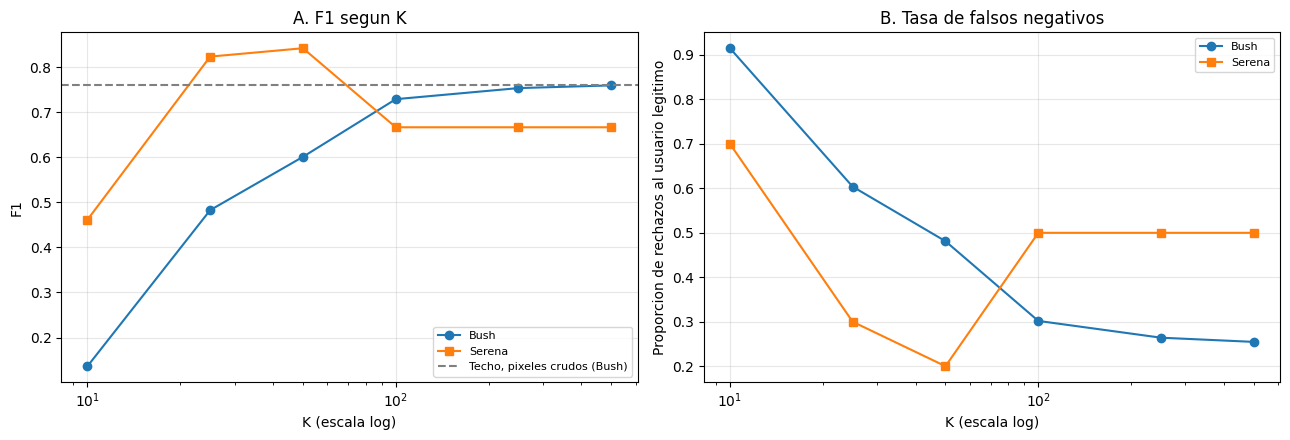

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# A. Desempeño frente al techo de pixeles crudos
axes[0].plot(consolidado["K"], consolidado["Bush_F1"], marker="o", label="Bush")
axes[0].plot(consolidado["K"], consolidado["Serena_F1"], marker="s", label="Serena")
axes[0].axhline(raw_bush["F1"], linestyle="--", color="grey",
                label="Techo, pixeles crudos (Bush)")
axes[0].set_xscale("log")
axes[0].set_xlabel("K (escala log)")
axes[0].set_ylabel("F1")
axes[0].set_title("A. F1 segun K")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# B. Tasa de rechazo al usuario legitimo, que es lo que sufre el empleado
axes[1].plot(consolidado["K"], 1 - consolidado["Bush_recall"], marker="o", label="Bush")
axes[1].plot(consolidado["K"], 1 - consolidado["Serena_recall"], marker="s", label="Serena")
axes[1].set_xscale("log")
axes[1].set_xlabel("K (escala log)")
axes[1].set_ylabel("Proporcion de rechazos al usuario legitimo")
axes[1].set_title("B. Tasa de falsos negativos")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**La recomendación es $K = 100$**, con $K = 250$ como alternativa si el cliente prioriza desempeño por encima de memoria.

El razonamiento, por partes.

**Por debajo de 100 el sistema no es utilizable.** Con $K = 10$ el modelo queda por debajo de la referencia ingenua. Con $K = 25$ y $K = 50$ el F1 de Bush es 0.48 y 0.60, es decir entre el 63% y el 79% del techo alcanzable. No es un ahorro, es un sistema que no funciona.

**Por encima de 100 la ganancia se agota rápido.** Pasar de 100 a 250 sube el F1 de Bush de 0.729 a 0.754, unos 2.5 puntos, y **no mejora nada a Serena**, que se queda en 0.667. A cambio, el almacenamiento por empleado se multiplica por 2.5, de 3.4% a 8.6%, y el punto de equilibrio sube de 105 a 275 empleados. Para un hardware con poca memoria, que es la restricción declarada del caso, ese intercambio no se justifica.

**Con $K = 100$ se llega al 96% del techo.** El F1 de Bush es 0.729 contra 0.761 de los 2914 píxeles crudos, usando el 3.4% de las dimensiones. La compresión no es lo que limita al sistema.

Ahora bien, y esto es lo que hay que decirle al cliente sin adornos: **elegir bien $K$ no arregla el problema de fondo**. Incluso en la mejor configuración, y aun usando los píxeles crudos sin comprimir, el sistema rechaza a Bush una de cada cuatro veces y a Serena una de cada dos. Ningún valor de $K$ corrige eso, porque el cuello de botella no es la representación sino cuántas imágenes por persona vio el sistema y qué tan parecida es esa persona al resto de la base.

Esa es la conclusión que llevamos al Paso 6.

### Cierre del Paso 5

1. **La SVD se calcula solo con entrenamiento** y la base es única y compartida, tal como exige el caso de negocio. Sin esas dos decisiones, ni la evaluación sería creíble ni el argumento de costo se sostendría.
2. **El accuracy es engañoso aquí.** Con $K = 10$ el modelo de Bush queda por debajo de la referencia ingenua, y con Serena cualquier configuración supera el 98% simplemente porque ella es el 2% de la muestra.
3. **La compresión no es el problema.** Con $K = 250$ se alcanza prácticamente el mismo F1 que con los 2914 píxeles crudos.
4. **El sistema no funciona igual para todos.** Serena es rechazada el 50% de las veces contra el 25% de Bush, y eso no mejora ni con más dimensiones ni sin comprimir. La causa está en la composición de la base, 42 imágenes suyas en entrenamiento contra 424 de Bush.
5. **Recomendamos $K = 100$**, con la advertencia explícita de que ningún $K$ resuelve las tasas de rechazo observadas.

<a id='paso6'></a>
## Paso 6. Recomendación

### 6.1 La recomendación

**No recomendamos reemplazar las tarjetas por reconocimiento facial. Sí recomendamos aprobar un piloto acotado en el que el reconocimiento facial opere como complemento, con la tarjeta como respaldo obligatorio.**

El motivo es directo y está en los números del Paso 5. En la mejor configuración disponible, **el sistema rechaza al empleado legítimo entre el 25% y el 50% de las veces** según de quién se trate, y acepta como Bush a 23 de 412 imágenes de otras personas, un 5.6% de falsa aceptación.

Un torniquete que es la única puerta de entrada no puede rechazar a uno de cada cuatro empleados en su mejor caso. Y un sistema de control de acceso no puede dejar pasar a uno de cada dieciocho desconocidos que lo intenten.

Es importante ser precisos sobre qué falló, porque determina si vale la pena insistir. **No falló la compresión.** Con $K = 250$ el desempeño es prácticamente idéntico al de usar los 2914 píxeles crudos, y el ahorro de almacenamiento es real y grande. Lo que no alcanza es el **poder de discriminación del enfoque de eigenfaces** con los datos disponibles. Por eso la recomendación no es "comprimir menos", es "no darle a este sistema la responsabilidad de ser el único filtro".

### 6.2 Con qué $K$ y con qué desempeño esperado

**$K = 100$.** Cada empleado cuesta 100 números frente a los 2914 de la imagen cruda, es decir el **3.4%**, un ahorro del 96.6%. Con esa configuración se captura el 90% de la varianza y se alcanza el 96% del F1 que darían los píxeles sin comprimir. La base compartida se amortiza a partir de 105 empleados.

Lo que el cliente debe esperar, sin maquillaje, medido sobre LFW:

| Métrica | Usuario bien representado (Bush) | Usuario poco representado (Serena) |
|---|---|---|
| Rechazos al empleado legítimo | 30% | 50% |
| Falsa aceptación de un extraño | 5.6% | 0% |
| Precisión | 0.76 | 1.00 |
| Imágenes disponibles para entrenar | 424 | 42 |

Estas cifras **no son la promesa de desempeño en producción**, son lo que obtuvimos sobre una base pública que no representa a la nómina del cliente. Sirven para dimensionar el orden de magnitud del problema, no para comprometer un nivel de servicio.

Subir a $K = 250$ mejora el F1 de Bush en 2.5 puntos y **no mejora nada a Serena**, a cambio de multiplicar el almacenamiento por 2.5. Dado que la restricción declarada del caso es hardware con poca memoria, no lo justificamos.

### 6.3 Salvaguardas operativas

Si el comité aprueba el piloto en la modalidad de complemento, estas son las condiciones mínimas.

**Sobre el acceso**

1. **La tarjeta se conserva y es el método de respaldo obligatorio.** El reconocimiento facial acelera el paso de quienes reconoce, nunca bloquea a quien no reconoce.
2. **Ningún empleado debe quedar sin poder entrar** por una decisión del algoritmo. El torniquete falla hacia la tarjeta, no hacia la puerta cerrada.
3. **El umbral de decisión debe ser configurable**, no el 0.5 por defecto del clasificador. Permite mover el balance entre falsos positivos y falsos negativos según la zona: más estricto en áreas sensibles, más permisivo en el acceso general.

**Sobre la equidad**

4. **Mínimo de imágenes de enrolamiento por empleado**, capturadas en condiciones variadas de luz y pose. La diferencia entre Bush y Serena en nuestro análisis se explica en buena medida por 424 imágenes contra 42.
5. **Auditoría de desempeño desagregada por subgrupo** antes de escalar y de forma periódica después, con un umbral explícito de disparidad aceptable. Reportar solo el promedio habría ocultado por completo el caso de Serena.
6. **Canal de reporte para empleados rechazados de forma reiterada**, con revisión y reenrolamiento. Sin esto, el problema es invisible para la administración y visible todos los días para quien lo sufre.

**Sobre la operación**

7. **Detección y alineación del rostro antes de proyectar.** Como vimos en el Paso 2, todo el método depende de que las caras estén centradas y recortadas de forma consistente. La cámara de un torniquete no entrega eso por sí sola.
8. **Reentrenar la base de eigenfaces con fotos propias de los empleados**, no con LFW. La base actual está ajustada a rostros de prensa de hace veinte años.

### 6.4 Limitaciones que el cliente debe conocer

**La base no representa a la población de empleados.** LFW se compiló hacia 2007 con fotos de prensa de figuras públicas. Las cinco personas más fotografiadas son hombres en cargos públicos, y una sola de ellas concentra el 20% de las imágenes. La nómina de un edificio corporativo no se parece a eso ni en composición demográfica, ni en rango de edad, ni en condiciones de fotografía.

**Las fotos son antiguas y de otro contexto.** Son imágenes de prensa, tomadas por fotógrafos profesionales, con encuadres y calidad que no se parecen a lo que capturará una cámara sencilla en un lobby.

**Lo que esta evaluación no midió.** Es una lista importante porque delimita hasta dónde llega nuestra evidencia:

- Robustez frente a **intentos deliberados de suplantación**, como presentar una fotografía impresa, una pantalla o una máscara. Nada en este análisis prueba que el sistema resista un ataque intencional.
- Desempeño con **personas físicamente parecidas** entre sí, incluidos familiares o gemelos.
- Efecto del **envejecimiento** y de cambios de apariencia como barba, lentes, corte de pelo o mascarilla.
- Comportamiento con las **condiciones reales de la cámara del torniquete**, iluminación del lobby, contraluz, personas en movimiento, ángulo de la cámara.
- **Tiempo de respuesta y consumo** en el hardware previsto. Medimos almacenamiento, no latencia.
- Desempeño con **rostros nunca vistos** durante la construcción de la base. Nuestra evaluación usó personas que sí estaban en el entrenamiento, aunque con imágenes distintas.

**Implicaciones éticas y de privacidad.** Este punto merece atención propia porque es donde el proyecto tiene más exposición.

Un rostro es un **dato biométrico irrevocable**. Si se filtra una tarjeta, se emite otra. Si se filtra la representación facial de un empleado, no hay forma de emitirle una cara nueva.

Y conviene desmontar una idea cómoda: **guardar 100 coordenadas en vez de la foto no anonimiza a nadie**. En el Paso 4 demostramos exactamente lo contrario, que con esas coordenadas y la base compartida se reconstruye un rostro reconocible. Las coordenadas son dato biométrico comprimido, no un token anónimo, y deben protegerse con el mismo estándar que una fotografía.

A eso se suma la necesidad de consentimiento informado y de una alternativa real para quien no quiera participar, límites claros de retención y de finalidad, y la advertencia de que un sistema instalado para abrir puertas es técnicamente capaz de registrar quién entró, a qué hora y con qué frecuencia. Esa capacidad de vigilancia debe estar explícitamente acotada por política, no solo por buena intención.

**Sensibilidad a nuestras propias decisiones metodológicas.** Los resultados dependen de elecciones que tomamos y documentamos:

- **Paso 2.** Centrar es obligatorio. No estandarizar fue una decisión justificada por la escala común de los píxeles, y estandarizar habría amplificado el ruido del fondo.
- **Paso 5.** Calcular la SVD solo con entrenamiento. Si hubiéramos usado toda la base, **las métricas se verían mejor de lo que son** y estaríamos entregando una evaluación inflada. Del mismo modo, usar una sola partición y una sola base compartida es lo que hace comparables a Bush y a Serena.

Si el cliente compara nuestras cifras con las de otro proveedor, debe verificar que ese proveedor haya tomado las mismas precauciones. Es fácil reportar un accuracy mucho más alto simplemente relajándolas.

### 6.5 Qué haría falta para reconsiderar el reemplazo total

La recomendación de no reemplazar las tarjetas no es definitiva, es una lectura de la evidencia disponible hoy. Se podría revisar si se cumplen estas condiciones, en este orden:

1. **Repetir el análisis con fotos propias de los empleados**, con un mínimo de imágenes por persona y capturadas con la cámara del torniquete. Es el paso que más puede cambiar los resultados, porque el cuello de botella que encontramos fue la cantidad y representatividad de las imágenes, no la compresión.
2. **Fijar con el cliente los umbrales aceptables** antes de medir: qué tasa de rechazo tolera la operación y qué tasa de falsa aceptación tolera seguridad. Sin esos números acordados de antemano, cualquier resultado se puede narrar como éxito.
3. **Verificar que la disparidad entre subgrupos esté dentro del umbral acordado**, no solo el promedio general.
4. **Evaluar la resistencia a suplantación** con pruebas deliberadas.
5. Si tras eso el desempeño sigue sin alcanzar los umbrales, la conclusión sería que el enfoque de eigenfaces no es adecuado para este uso, y correspondería evaluar métodos más modernos aceptando su mayor costo de hardware.

**La decisión concreta que se solicita al comité** es aprobar el piloto en modalidad de complemento con $K = 100$, con presupuesto para recolectar imágenes propias de empleados, y con el compromiso de fijar los umbrales de aceptación antes de la siguiente medición.

### Cierre del Paso 6

1. **Recomendación: no reemplazar las tarjetas, sí aprobar un piloto como complemento** con respaldo obligatorio de tarjeta.
2. **$K = 100$**, que cuesta el 3.4% del almacenamiento de la foto cruda y alcanza el 96% del desempeño máximo del método.
3. **Lo que falla no es la compresión sino el poder de discriminación.** Con los 2914 píxeles sin comprimir el resultado es prácticamente el mismo.
4. **El sistema no trata igual a todos.** El rechazo va del 25% al 50% según la persona, y la causa está en la representación en los datos de entrenamiento.
5. **Las coordenadas comprimidas siguen siendo dato biométrico.** Lo demostramos nosotros mismos al reconstruir rostros reconocibles a partir de ellas.

<a id='impostor'></a>
## Extensión. El juego del impostor

Hay un hueco en todo lo que medimos hasta aquí, y es importante nombrarlo.

Cuando en el Paso 5 contamos falsos positivos, esos "extraños" no eran realmente extraños. Eran personas que el sistema **sí había visto en entrenamiento**, solo que con otras fotografías, y que además habían participado en construir las eigenfaces. En un edificio real, quien intenta entrar sin autorización es alguien que el sistema nunca vio y que no contribuyó en nada a definir la base.

Esta extensión cierra ese hueco. Reservamos varias identidades completas, con todas sus imágenes, y las excluimos por completo: no entran al entrenamiento, no entran a la prueba y **no participan en construir las eigenfaces**. Después presentamos sus fotos en el torniquete como intentos de acceso y contamos cuántas se aceptan como si fueran el usuario piloto.

Eso es una tasa de falsa aceptación frente a desconocidos reales, que es la cifra que de verdad le importa a seguridad.

In [35]:
# Reservamos identidades completas como impostores.
# No pueden ser los usuarios piloto, porque a ellos si hay que reconocerlos.
rng = np.random.RandomState(10101)

nombres_piloto = ["George W Bush", "Serena Williams"]
ids_piloto = [np.where(lfw.target_names == n)[0][0] for n in nombres_piloto]

candidatos = np.array([i for i in range(len(lfw.target_names)) if i not in ids_piloto])
ids_impostores = np.sort(rng.choice(candidatos, size=8, replace=False))

es_impostor = np.isin(lfw.target, ids_impostores)

print("Identidades reservadas como impostores, nunca vistas por el sistema:\n")
for i in ids_impostores:
    print(f"  {lfw.target_names[i]:32} {(lfw.target == i).sum():4} imagenes")

print(f"\nImagenes de impostores : {es_impostor.sum()}")
print(f"Imagenes conocidas     : {(~es_impostor).sum()}")

Identidades reservadas como impostores, nunca vistas por el sistema:

  Alvaro Uribe                       35 imagenes
  Jacques Chirac                     52 imagenes
  John Ashcroft                      53 imagenes
  John Negroponte                    31 imagenes
  Kofi Annan                         32 imagenes
  Megawati Sukarnoputri              33 imagenes
  Nestor Kirchner                    37 imagenes
  Roh Moo-hyun                       32 imagenes

Imagenes de impostores : 305
Imagenes conocidas     : 2283


In [36]:
# Reconstruimos TODO el pipeline sin los impostores:
# particion, rostro promedio y base de eigenfaces.
idx_conocidos = np.where(~es_impostor)[0]
idx_impostores = np.where(es_impostor)[0]

idx_tr2, idx_te2 = train_test_split(
    idx_conocidos,
    test_size=0.20,
    random_state=10101,
    stratify=lfw.target[idx_conocidos]
)

X_tr2 = lfw.data[idx_tr2]
X_te2 = lfw.data[idx_te2]
X_imp = lfw.data[idx_impostores]

# El rostro promedio tampoco puede saber de los impostores
media2 = X_tr2.mean(axis=0)

Xtr2_c = X_tr2 - media2
Xte2_c = X_te2 - media2
Ximp_c = X_imp - media2

U2, S2, Vt2 = np.linalg.svd(Xtr2_c, full_matrices=False)

print("Entrenamiento :", X_tr2.shape)
print("Prueba        :", X_te2.shape)
print("Impostores    :", X_imp.shape)
print("\nBase de eigenfaces construida sin ninguna imagen de impostor")

Entrenamiento : (1826, 2914)
Prueba        : (457, 2914)
Impostores    : (305, 2914)

Base de eigenfaces construida sin ninguna imagen de impostor


In [37]:
# Usuario piloto: Bush. Ningun impostor es Bush, por construccion.
y_bush_total = (lfw.target == ids_piloto[0]).astype(int)
y_tr2 = y_bush_total[idx_tr2]
y_te2 = y_bush_total[idx_te2]

filas = []
for K in Ks:
    Vk = Vt2[:K, :]

    Z_tr = Xtr2_c @ Vk.T
    Z_te = Xte2_c @ Vk.T
    Z_imp = Ximp_c @ Vk.T

    modelo = LogisticRegression(solver="sag", random_state=10101, max_iter=1000)
    modelo.fit(Z_tr, y_tr2)

    pred_te = modelo.predict(Z_te)
    pred_imp = modelo.predict(Z_imp)

    # Extraños CONOCIDOS: en la prueba, los que no son Bush pero si
    # participaron en entrenamiento y en construir las eigenfaces
    mask_no_bush = (y_te2 == 0)
    fp_conocidos = int(pred_te[mask_no_bush].sum())
    tasa_conocidos = pred_te[mask_no_bush].mean()

    # Impostores: nunca vistos, no participaron en nada
    fp_impostores = int(pred_imp.sum())
    tasa_impostores = pred_imp.mean()

    filas.append({
        "K": K,
        "recall_Bush": recall_score(y_te2, pred_te, zero_division=0),
        "FP_extraños_conocidos": fp_conocidos,
        "de_un_total_de": int(mask_no_bush.sum()),
        "tasa_conocidos": tasa_conocidos,
        "FP_impostores": fp_impostores,
        "de_impostores": len(idx_impostores),
        "tasa_impostores": tasa_impostores,
    })

impostores = pd.DataFrame(filas)
impostores.round(4)

,K,recall_Bush,FP_extraños_conocidos,de_un_total_de,tasa_conocidos,FP_impostores,de_impostores,tasa_impostores
0,10,0.2264,15,351,0.0427,5,305,0.0164
1,25,0.3396,28,351,0.0798,8,305,0.0262
2,50,0.5377,15,351,0.0427,5,305,0.0164
3,100,0.6981,19,351,0.0541,8,305,0.0262
4,250,0.7358,18,351,0.0513,8,305,0.0262
5,500,0.7264,19,351,0.0541,10,305,0.0328


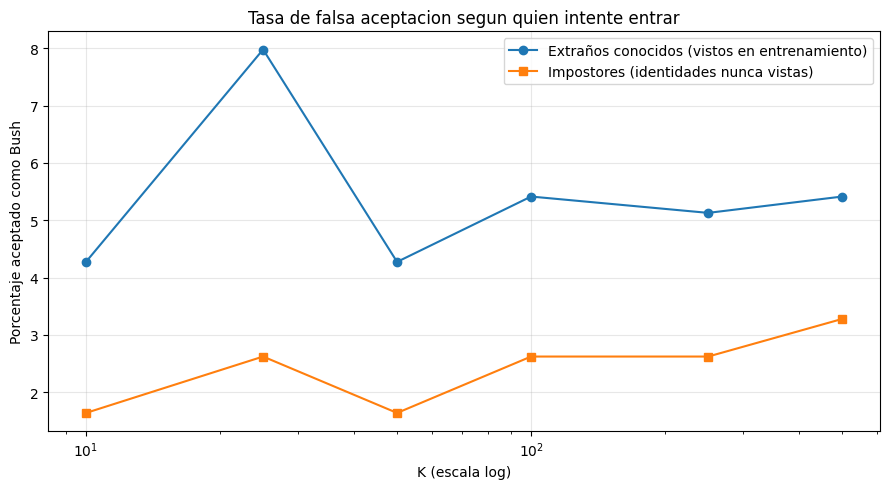

In [38]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(impostores["K"], impostores["tasa_conocidos"] * 100,
        marker="o", label="Extraños conocidos (vistos en entrenamiento)")
ax.plot(impostores["K"], impostores["tasa_impostores"] * 100,
        marker="s", label="Impostores (identidades nunca vistas)")

ax.set_xscale("log")
ax.set_xlabel("K (escala log)")
ax.set_ylabel("Porcentaje aceptado como Bush")
ax.set_title("Tasa de falsa aceptacion segun quien intente entrar")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**El resultado contradijo nuestra hipótesis, y conviene decirlo así**

Esperábamos que los impostores fueran aceptados con **más** frecuencia que los extraños conocidos, porque nunca habían sido vistos ni habían participado en construir las eigenfaces. Salió lo contrario.

| $K$ | Extraños conocidos aceptados | Impostores aceptados |
|---|---|---|
| 10 | 4.3% | 1.6% |
| 25 | 8.0% | 2.6% |
| 50 | 4.3% | 1.6% |
| **100** | **5.4%** | **2.6%** |
| 250 | 5.1% | 2.6% |
| 500 | 5.4% | 3.3% |

Los impostores son aceptados a **aproximadamente la mitad** de la tasa de los extraños conocidos, de forma consistente en toda la grilla.

**Por qué, y por qué no hay que celebrarlo.** La explicación más probable no es que el sistema sea más robusto ante desconocidos, sino **quiénes quedaron reservados**. Entre los ocho impostores hay varias personas visualmente muy distintas de Bush, como Kofi Annan, Megawati Sukarnoputri y Roh Moo-hyun. El grupo de extraños conocidos, en cambio, conserva a buena parte de los políticos occidentales de mediana edad de la base, que se parecen bastante más a él.

A eso se suma que los conteos son pequeños, entre 5 y 10 aceptaciones sobre 305 imágenes. Con esos números, un par de casos hacia arriba o abajo mueve la tasa varios puntos.

**Conclusión honesta: esta prueba no demuestra que el sistema sea más seguro frente a desconocidos.** Demuestra que la tasa de falsa aceptación depende fuertemente de a quién se parezca el impostor, que es justo lo que uno esperaría de un método basado en distancias en un espacio de rostros. Un atacante que se pareciera deliberadamente al empleado suplantado enfrentaría una tasa mucho más favorable que el 2.6% observado.

Lo que sí queda firme es el orden de magnitud: **entre el 1.6% y el 3.3% de los intentos de personas totalmente desconocidas son aceptados como Bush.** No es un riesgo marginal.

**El problema se multiplica con el número de empleados**

Hay una consecuencia que ninguna de nuestras tablas anteriores hacía visible, y es probablemente el argumento de seguridad más importante de todo el análisis.

Todo lo que medimos son clasificadores binarios **por usuario**. En un despliegue real con cientos de empleados enrolados, un extraño que se presenta al torniquete no enfrenta una prueba, enfrenta **tantas pruebas como empleados haya**, y le basta con que una sola lo acepte para entrar.

La cuenta siguiente ilustra la magnitud. Es deliberadamente simplificada, supone independencia entre los clasificadores, cosa que no es cierta porque comparten la misma base de eigenfaces. Sirve para mostrar la dirección del efecto, no como estimación precisa.

In [39]:
# Ilustracion del riesgo a nivel sistema.
# Supuesto fuerte: independencia entre los clasificadores de cada empleado.
# No se cumple, comparten la misma base, pero muestra la direccion del efecto.
tasa_individual = impostores.loc[impostores["K"] == 100, "tasa_impostores"].iloc[0]

print(f"Tasa de falsa aceptacion por usuario (K=100): {tasa_individual:.2%}\n")
print("Probabilidad de que un desconocido sea aceptado como ALGUN empleado:\n")

for n_empleados in [1, 10, 50, 100, 250, 500]:
    p = 1 - (1 - tasa_individual) ** n_empleados
    print(f"  {n_empleados:4} empleados enrolados -> {p:7.2%}")

print("\nPara que el riesgo agregado quede por debajo del 5% con 500 empleados,")
objetivo = 1 - (1 - 0.05) ** (1 / 500)
print(f"la tasa por usuario tendria que bajar a {objetivo:.4%},")
print(f"es decir unas {tasa_individual / objetivo:.0f} veces menos que la actual.")

Tasa de falsa aceptacion por usuario (K=100): 2.62%

Probabilidad de que un desconocido sea aceptado como ALGUN empleado:

     1 empleados enrolados ->   2.62%
    10 empleados enrolados ->  23.34%
    50 empleados enrolados ->  73.53%
   100 empleados enrolados ->  92.99%
   250 empleados enrolados ->  99.87%
   500 empleados enrolados -> 100.00%

Para que el riesgo agregado quede por debajo del 5% con 500 empleados,
la tasa por usuario tendria que bajar a 0.0103%,
es decir unas 256 veces menos que la actual.


**Qué significa esto para la recomendación**

El cálculo anterior refuerza y precisa la postura del Paso 6.

Una tasa de falsa aceptación del 2.6% por usuario suena manejable leída de a una. Leída a escala de un edificio con cientos de empleados enrolados, **deja de serlo por completo**: cualquier desconocido que se presente al torniquete tiene una probabilidad muy alta de parecerse lo suficiente a alguno de los enrolados.

Esto no invalida el uso del sistema, invalida un uso concreto: **el reconocimiento facial no puede ser la única puerta**. Como complemento de la tarjeta el riesgo es aceptable, porque el rostro acelera el paso de quien ya se autenticó por otro medio. Como reemplazo, la aritmética no cierra.

También precisa qué habría que exigirle a una versión mejorada. No basta con "mejorar el accuracy". Habría que **bajar la tasa de falsa aceptación por usuario en dos órdenes de magnitud** para que el riesgo agregado sea tolerable en un edificio de varios cientos de personas. Ese es el umbral concreto que debería fijarse antes de volver a medir, tal como planteamos en la sección 6.5.

### Cierre de la extensión

1. Reservamos **8 identidades completas**, 305 imágenes, excluidas del entrenamiento, de la prueba y de la construcción de las eigenfaces.
2. **Entre el 1.6% y el 3.3% de sus intentos son aceptados como Bush**, según $K$.
3. Esa tasa resultó **menor** que la de los extraños conocidos, contra nuestra expectativa. La explicación más plausible es que el grupo reservado se parece poco a Bush, no que el sistema sea robusto ante desconocidos. Con conteos de 5 a 10 casos, la estimación es además ruidosa.
4. El hallazgo importante es otro: **el riesgo se multiplica con el número de empleados enrolados**, porque cada uno es una oportunidad adicional de coincidencia. Es el argumento más fuerte para no usar el sistema como único método de acceso.